<a href="https://colab.research.google.com/github/CapSeaCalf/psychometrics/blob/main/psychometrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
DATA_PATH = '/content/drive/MyDrive/psychometrics/дані для тг.xlsx'

In [32]:
df = pd.read_excel(DATA_PATH)
df.head()

,Позначка часу,вік,стать,діяльність,місце_проживання,gasp_1,gasp_2,gasp_3,gasp_4,gasp_5,...,gasp_7,gasp_8,gasp_9,gasp_10,gasp_11,gasp_12,gasp_13,gasp_14,gasp_15,gasp_16
0,2026-04-23 20:49:48.767,2,2,1,1,6,4,6,3,6,...,1,3,5,6,5,4,6,6,5,3
1,2026-04-23 21:00:46.082,2,2,3,1,6,6,6,5,2,...,7,6,4,6,4,5,5,6,4,3
2,2026-04-23 21:11:07.659,2,2,3,5,5,6,5,7,7,...,4,4,5,6,6,5,3,6,6,7
3,2026-04-23 21:35:59.829,2,2,4,5,5,5,5,5,5,...,3,7,5,7,6,5,7,7,3,2
4,2026-04-23 21:43:50.968,2,2,2,1,2,6,7,3,5,...,6,5,4,7,6,3,5,4,6,3


In [33]:
df.describe()

,Позначка часу,вік,стать,діяльність,місце_проживання,gasp_1,gasp_2,gasp_3,gasp_4,gasp_5,...,gasp_7,gasp_8,gasp_9,gasp_10,gasp_11,gasp_12,gasp_13,gasp_14,gasp_15,gasp_16
count,478,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,...,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000
mean,2026-04-28 15:02:05.770035712,2.372385,1.474895,2.364017,1.951883,5.759414,5.343096,5.688285,4.430962,5.330544,...,4.891213,4.575314,4.631799,6.169456,5.230126,4.970711,5.412134,5.359833,5.330544,4.058577
min,2026-04-23 20:49:48.767000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2026-04-28 09:43:58.176749824,2.000000,1.000000,2.000000,1.000000,5.000000,4.000000,5.000000,3.000000,4.000000,...,3.000000,3.000000,3.000000,6.000000,4.000000,3.000000,5.000000,4.000000,4.000000,2.000000
50%,2026-04-28 13:27:15.885499904,2.000000,1.000000,2.000000,1.000000,7.000000,6.000000,6.000000,5.000000,6.000000,...,5.000000,5.000000,5.000000,7.000000,6.000000,5.000000,6.000000,6.000000,6.000000,4.000000
75%,2026-04-29 05:11:28.638750208,3.000000,2.000000,3.000000,2.000000,7.000000,7.000000,7.000000,6.000000,7.000000,...,7.000000,6.000000,6.000000,7.000000,6.000000,7.000000,7.000000,7.000000,7.000000,6.000000
max,2026-05-03 23:17:20.147000,5.000000,3.000000,7.000000,5.000000,7.000000,7.000000,7.000000,7.000000,7.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
std,NaN,0.784701,0.516395,1.213707,1.421528,1.755096,1.690851,1.774827,1.923714,1.678433,...,1.893575,1.858060,2.016284,1.331189,1.581262,1.988220,1.721616,1.759138,1.698300,1.910119


In [34]:
df['стать'].unique()

array([2, 1, 3])

In [35]:
df['стать'].value_counts()

,count
стать,
1,255
2,219
3,4


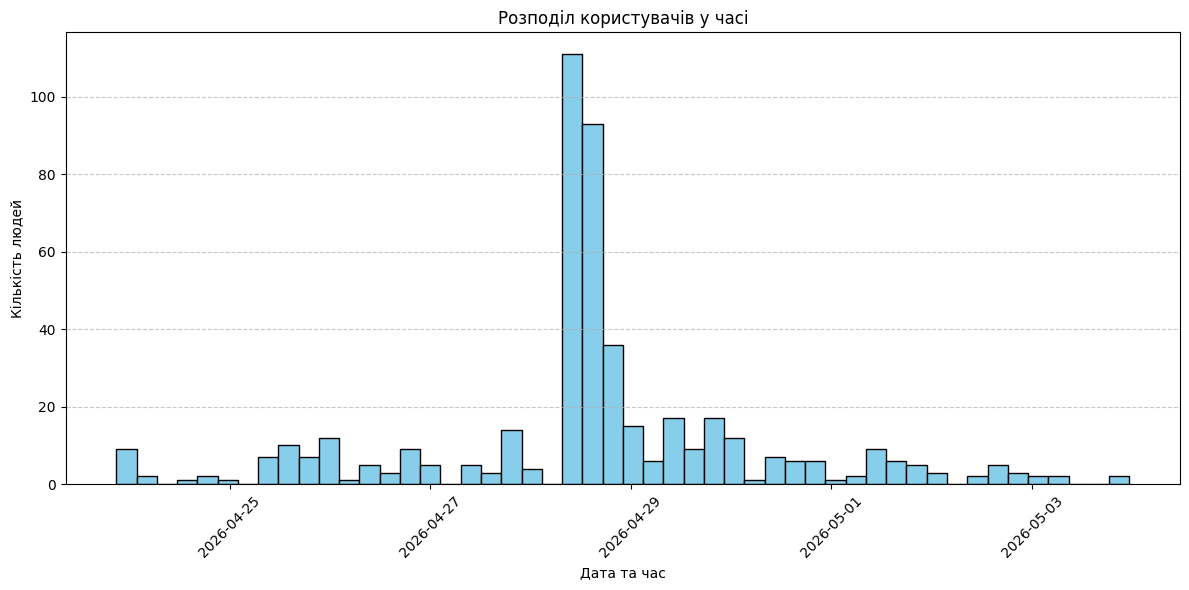

In [36]:
df['Позначка часу'] = pd.to_datetime(df['Позначка часу'])

# 2. Будуємо гістограму
plt.figure(figsize=(12, 6))
plt.hist(df['Позначка часу'], bins=50, color='skyblue', edgecolor='black')

plt.title('Розподіл користувачів у часі')
plt.xlabel('Дата та час')
plt.ylabel('Кількість людей')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Більшість користувачів прийшли із посту на Reddit

In [37]:
import numpy as np
df['before_reddit'] = pd.Series(np.where(df['Позначка часу'] < '2026-04-28 00:00:00', 1, 0))

In [38]:
df['before_reddit']

,before_reddit
0,1
1,1
2,1
3,1
4,1
...,...
473,0
474,0
475,0
476,0


In [39]:
to_reduce = df.iloc[:, 5:21]

In [40]:
reducer = umap.UMAP(n_components=2, min_dist=0.3)

dots = reducer.fit_transform(to_reduce)

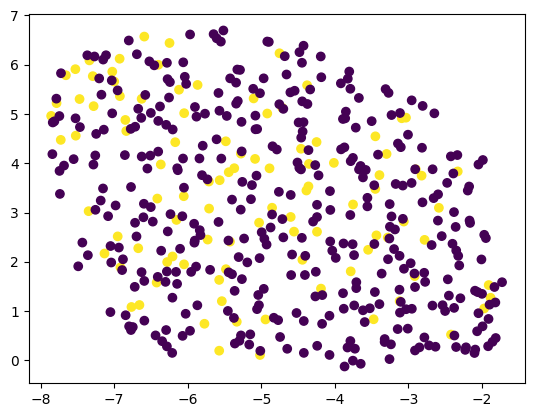

In [41]:
plt.scatter(dots[:, 0], dots[:, 1], c = df['before_reddit'])

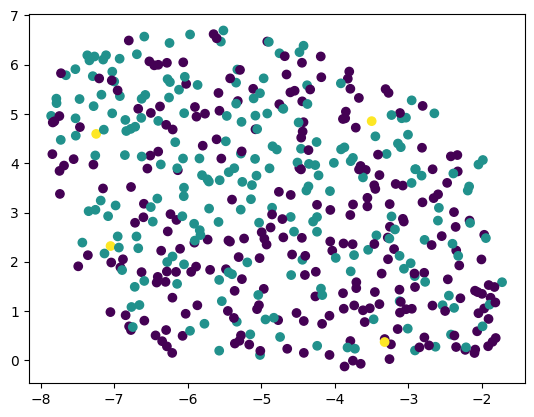

In [42]:
plt.scatter(dots[:, 0], dots[:, 1], c = df['стать'])

Якихось одрузу помітних кластерів не виявлено

In [43]:
! pip install pingouin

In [44]:
import pingouin as pg

print(pg.cronbach_alpha(data=to_reduce))

(np.float64(0.8070661909900724), array([0.781, 0.831]))


In [45]:
GUILT1 = df[['gasp_1', 'gasp_9', 'gasp_14', 'gasp_16']]
GUILT2 = df[['gasp_2', 'gasp_5', 'gasp_11', 'gasp_15']]
SHAME1 = df[['gasp_3', 'gasp_6', 'gasp_10', 'gasp_13']]
SHAME2 = df[['gasp_4', 'gasp_7', 'gasp_8', 'gasp_12']]

In [46]:
print(pg.cronbach_alpha(data=GUILT1))

(np.float64(0.6518373040832799), array([0.598, 0.7  ]))


In [47]:
print(pg.cronbach_alpha(data=GUILT2[df['стать'] == 2]))

(np.float64(0.4808467786972182), array([0.359, 0.585]))


In [48]:
print(pg.cronbach_alpha(data=SHAME1))

(np.float64(0.5936025850155722), array([0.531, 0.65 ]))


In [49]:
print(pg.cronbach_alpha(data=SHAME2))

(np.float64(0.6924032893949159), array([0.645, 0.735]))


Друга група показує найгіршу узгодженість

In [50]:
print(pg.cronbach_alpha(data=SHAME1[df['before_reddit'] == 0]))

(np.float64(0.5960016010892082), array([0.525, 0.659]))


In [51]:
print(pg.cronbach_alpha(data=SHAME1[df['before_reddit'] == 1]))

(np.float64(0.5435636359815379), array([0.378, 0.674]))


In [52]:
GUILT1.corr()

,gasp_1,gasp_9,gasp_14,gasp_16
gasp_1,1.000000,0.252760,0.216865,0.254351
gasp_9,0.252760,1.000000,0.324095,0.416044
gasp_14,0.216865,0.324095,1.000000,0.438561
gasp_16,0.254351,0.416044,0.438561,1.000000


In [53]:
subset = GUILT2[df['стать'] == 1]

print(f"Початкова альфа групи: {pg.cronbach_alpha(data=subset)[0]:.3f}\n")

# Цикл для перевірки 'Alpha if item deleted'
for item in subset.columns:
    # Створюємо список без одного поточного елемента
    reduced_items = [i for i in subset.columns if i != item]
    alpha, ci = pg.cronbach_alpha(data=subset[reduced_items])
    print(f"Альфа БЕЗ {item}: {alpha:.3f} (CI: {ci})")

Початкова альфа групи: 0.477

Альфа БЕЗ gasp_2: 0.470 (CI: [0.347 0.574])
Альфа БЕЗ gasp_5: 0.369 (CI: [0.221 0.492])
Альфа БЕЗ gasp_11: 0.397 (CI: [0.257 0.515])
Альфа БЕЗ gasp_15: 0.382 (CI: [0.238 0.503])


In [54]:
subset = GUILT2[df['стать'] == 2]


print(subset)

print(f"Початкова альфа групи: {pg.cronbach_alpha(data=subset)[0]:.3f}\n")

# Цикл для перевірки 'Alpha if item deleted'
for item in subset.columns:
    # Створюємо список без одного поточного елемента
    reduced_items = [i for i in subset.columns if i != item]
    alpha, ci = pg.cronbach_alpha(data=subset[reduced_items])
    print(f"Альфа БЕЗ {item}: {alpha:.3f} (CI: {ci})")

     gasp_2  gasp_5  gasp_11  gasp_15
0         4       6        5        5
1         6       2        4        4
2         6       7        6        6
3         5       5        6        3
4         6       5        6        6
..      ...     ...      ...      ...
471       2       7        6        3
472       5       4        4        2
475       6       5        7        7
476       5       7        3        5
477       7       1        4        4

[219 rows x 4 columns]
Початкова альфа групи: 0.481

Альфа БЕЗ gasp_2: 0.563 (CI: [0.453 0.655])
Альфа БЕЗ gasp_5: 0.389 (CI: [0.234 0.517])
Альфа БЕЗ gasp_11: 0.310 (CI: [0.135 0.454])
Альфа БЕЗ gasp_15: 0.348 (CI: [0.182 0.484])


In [55]:
! pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=f76f24ffbef3e1ec2b3f65d3359a70e6e657afd047c47ef42ddb513c50f17f90
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [56]:
from factor_analyzer import FactorAnalyzer
fa = FactorAnalyzer(n_factors=2, rotation="promax")
fa.fit(to_reduce)
print(fa.get_factor_variance())
print(fa.loadings_)

(array([2.54362737, 2.11690649]), array([0.15897671, 0.13230666]), array([0.15897671, 0.29128337]))
[[ 0.41445264 -0.11862546]
 [ 0.33271237  0.05852113]
 [ 0.3514877   0.20938937]
 [-0.19642126  0.70450666]
 [ 0.41098806 -0.04964579]
 [ 0.11699308  0.45718146]
 [-0.06745025  0.65398726]
 [-0.13428679  0.7664402 ]
 [ 0.45814999  0.1532133 ]
 [ 0.33605365  0.31007238]
 [ 0.48878855 -0.13656176]
 [ 0.12119462  0.42622175]
 [ 0.55756987  0.05098039]
 [ 0.58858147  0.08657063]
 [ 0.49851571 -0.04227641]
 [ 0.64155033  0.02850707]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [57]:
group1 = [1,2, 3,5,9,10,11,13,14,15,16]
group2 = [4,6,7,8,10,12]

group1i = [i - 1 for i in group1]
group2i =[i - 1 for i in group2]

c = to_reduce.iloc[:,group1i].columns
d = to_reduce.iloc[:,group2i].columns

Провів перевірку на два фактори, оскільки хотів перевірити гіпотезу - користувачі на редіті жалілися на неможливість уявити себе у сценаріях із адаптованого тесту. Дослідившви оригінал, я побачив, що питання в ньому ніби поміщають респондента у ситуацію, де він опинився випадково. Таким чином, пиатння могли розділитися на два фактори - шкала GASP та простий тест на моральність. Цей тест служить непрямим доказом цієї концепції.

In [58]:
df2 = pd.read_excel('/content/drive/MyDrive/psychometrics/дані для тг (2).xlsx', sheet_name = '2025')
df2.head()

,група,вік,стать,діяльность,місце_проживання,@1_питання,@2_питання,@3_питання,@4_питання,@5_питання,...,@7_питання,@8_питання,@9_питання,@10_питання,@11_питання,@12_питання,@13_питання,@14_питання,@15_питання,@16_питання
0,1,2,2,1,1,7,6,7,3,7,...,4,2,6,7,6,6,4,6,5,5
1,1,2,2,3,3,4,7,7,3,2,...,5,1,3,7,6,2,1,1,1,1
2,1,2,2,3,1,5,6,7,7,7,...,6,7,7,7,7,7,7,7,7,5
3,1,2,2,3,1,7,5,7,7,4,...,4,2,7,7,2,3,6,6,4,6
4,1,2,2,1,4,7,4,7,6,7,...,3,3,7,7,6,6,7,7,3,7


Завантажую дані з пілотного дослідження

In [126]:
pg.cronbach_alpha(data = df2[['@2_питання', "@5_питання", '@11_питання', "@15_питання"]])

(np.float64(0.6085858585858587), array([0.441, 0.736]))

In [60]:
def z(a : pd.Series):
  return (a - a.mean()) / a.std()

def minmax(a : pd.Series):
  return (a - a.min())/(a.max() - a.min())

In [127]:
import seaborn as sns


In [62]:
to_reduce.corr()

,gasp_1,gasp_2,gasp_3,gasp_4,gasp_5,gasp_6,gasp_7,gasp_8,gasp_9,gasp_10,gasp_11,gasp_12,gasp_13,gasp_14,gasp_15,gasp_16
gasp_1,1.000000,0.107701,0.169030,-0.068575,0.039862,0.100350,0.058343,0.032890,0.252760,0.140417,0.123481,0.066466,0.202175,0.216865,0.165997,0.254351
gasp_2,0.107701,1.000000,0.253672,0.085284,0.101048,0.139111,0.097458,0.073835,0.180411,0.260987,0.141342,0.200679,0.293408,0.206502,0.129799,0.174865
gasp_3,0.169030,0.253672,1.000000,0.244513,0.196524,0.212499,0.178899,0.208975,0.372671,0.283280,0.151857,0.235048,0.292560,0.172309,0.197703,0.293569
gasp_4,-0.068575,0.085284,0.244513,1.000000,0.111618,0.305943,0.334036,0.431375,0.143149,0.208014,-0.016131,0.353557,0.112738,0.128778,0.047426,0.142595
gasp_5,0.039862,0.101048,0.196524,0.111618,1.000000,0.064148,0.066086,0.104935,0.159315,0.140956,0.254854,0.051280,0.170409,0.251455,0.257247,0.334635
gasp_6,0.100350,0.139111,0.212499,0.305943,0.064148,1.000000,0.308816,0.342656,0.282811,0.270394,0.081807,0.244179,0.238773,0.304119,0.127864,0.228516
gasp_7,0.058343,0.097458,0.178899,0.334036,0.066086,0.308816,1.000000,0.533835,0.230539,0.301746,0.038485,0.228015,0.123105,0.242751,0.165055,0.202892
gasp_8,0.032890,0.073835,0.208975,0.431375,0.104935,0.342656,0.533835,1.000000,0.206632,0.265632,0.075432,0.294558,0.130853,0.201426,0.171473,0.210222
gasp_9,0.252760,0.180411,0.372671,0.143149,0.159315,0.282811,0.230539,0.206632,1.000000,0.327912,0.152223,0.174064,0.252770,0.324095,0.217450,0.416044
gasp_10,0.140417,0.260987,0.283280,0.208014,0.140956,0.270394,0.301746,0.265632,0.327912,1.000000,0.152739,0.318717,0.344513,0.345434,0.163417,0.292902


(array([ 10.,  37.,  34.,  50.,  68., 125., 154.]),
 array([1.        , 1.85714286, 2.71428571, 3.57142857, 4.42857143,
        5.28571429, 6.14285714, 7.        ]),
 <BarContainer object of 7 artists>)

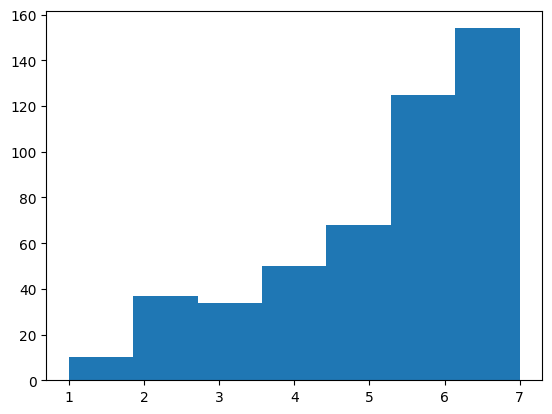

In [63]:
plt.hist(df['gasp_2'], bins = 7)

(array([ 1.,  8.,  3.,  7.,  9., 17., 30.]),
 array([1.        , 1.85714286, 2.71428571, 3.57142857, 4.42857143,
        5.28571429, 6.14285714, 7.        ]),
 <BarContainer object of 7 artists>)

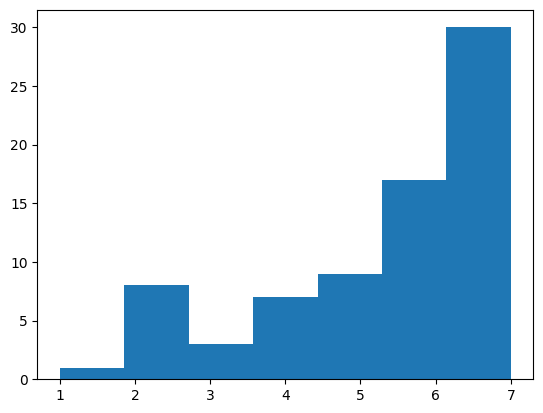

In [64]:
plt.hist(df2['@2_питання'], bins = 7)

Загалом, більшість графіків схожі.

In [65]:
subset = data = df2[df2['стать'] == 1][['@2_питання', "@5_питання", '@11_питання', "@15_питання"]]


print(subset)

print(f"Початкова альфа групи: {pg.cronbach_alpha(data=subset)[0]:.3f}\n")

# Цикл для перевірки 'Alpha if item deleted'
for item in subset.columns:
    # Створюємо список без одного поточного елемента
    reduced_items = [i for i in subset.columns if i != item]
    alpha, ci = pg.cronbach_alpha(data=subset[reduced_items])
    print(f"Альфа БЕЗ {item}: {alpha:.3f} (CI: {ci})")

    @2_питання  @5_питання  @11_питання  @15_питання
17           4           4            2            5
18           6           4            5            6
22           7           6            5            5
26           3           7            5            5
35           7           7            7            6
37           2           6            2            5
47           1           5            4            4
59           2           7            2            2
61           3           7            7            7
62           7           4            6            6
63           2           1            6            4
70           7           7            1            4
71           2           5            5            6
72           3           7            7            6
Початкова альфа групи: 0.421

Альфа БЕЗ @2_питання: 0.379 (CI: [-0.522  0.784])
Альфа БЕЗ @5_питання: 0.530 (CI: [-0.152  0.836])
Альфа БЕЗ @11_питання: 0.331 (CI: [-0.639  0.767])
Альфа БЕЗ @15_питання: 0

In [66]:
subset = data = df2[df2['стать'] == 2][['@2_питання', "@5_питання", '@11_питання', "@15_питання"]]


print(subset)

print(f"Початкова альфа групи: {pg.cronbach_alpha(data=subset)[0]:.3f}\n")

# Цикл для перевірки 'Alpha if item deleted'
for item in subset.columns:
    # Створюємо список без одного поточного елемента
    reduced_items = [i for i in subset.columns if i != item]
    alpha, ci = pg.cronbach_alpha(data=subset[reduced_items])
    print(f"Альфа БЕЗ {item}: {alpha:.3f} (CI: {ci})")

    @2_питання  @5_питання  @11_питання  @15_питання
0            6           7            6            5
1            7           2            6            1
2            6           7            7            7
3            5           4            2            4
4            4           7            6            3
..         ...         ...          ...          ...
67           4           5            6            5
68           6           3            4            5
69           7           6            7            7
73           7           7            7            7
74           5           7            7            6

[61 rows x 4 columns]
Початкова альфа групи: 0.646

Альфа БЕЗ @2_питання: 0.690 (CI: [0.526 0.804])
Альфа БЕЗ @5_питання: 0.498 (CI: [0.232 0.682])
Альфа БЕЗ @11_питання: 0.520 (CI: [0.266 0.697])
Альфа БЕЗ @15_питання: 0.569 (CI: [0.34  0.727])


In [ ]:
Друге питання вже тодібуло невдалим. 5 питання найцінніше у групі

In [67]:
l = len(to_reduce)
df['mean'] = pd.Series([])

for i in range(l):
  df['mean'][i] = to_reduce.loc[i].mean()

df['mean']

/tmp/ipykernel_8099/1084988167.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['mean'][i] = to_reduce.loc[i].mean()
/tmp/ipykernel_8099/1084988167.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

,mean
0,4.75
1,5.125
2,5.375
3,5.1875
4,4.875
...,...
473,3.1875
474,4.6875
475,6.625
476,4.625


In [68]:
l = len(to_reduce)
df['var'] = pd.Series([])

for i in range(l):
  df['var'][i] = to_reduce.loc[i].var()

df['var']

Показано результат, скорочений до останніх рядків (5000).
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['var'][i] = to_reduce.loc[i].var()
/tmp/ipykernel_8099/1839357979.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['var'][i] = to_reduce.loc[i].var()
/tmp/ipykernel_8099/1839357979.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical examp

,var
0,2.6
1,1.983333
2,1.45
3,2.295833
4,2.383333
...,...
473,4.429167
474,5.695833
475,0.383333
476,1.983333


(array([  3.,  14.,  45.,  96., 135., 130.,  55.]),
 array([2.        , 2.70535714, 3.41071429, 4.11607143, 4.82142857,
        5.52678571, 6.23214286, 6.9375    ]),
 <BarContainer object of 7 artists>)

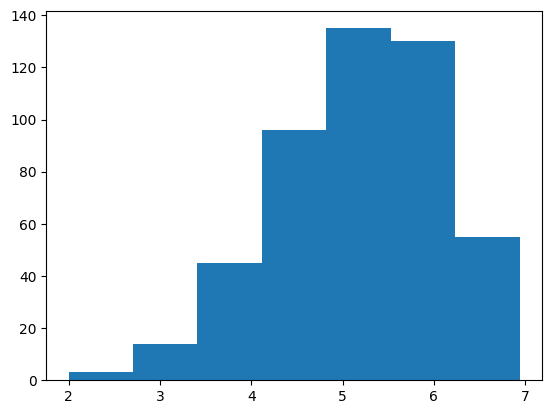

In [69]:
plt.hist(df['mean'], bins = 7)

Skewed distribution

In [70]:
df.corr()

,Позначка часу,вік,стать,діяльність,місце_проживання,gasp_1,gasp_2,gasp_3,gasp_4,gasp_5,...,gasp_10,gasp_11,gasp_12,gasp_13,gasp_14,gasp_15,gasp_16,before_reddit,mean,var
Позначка часу,1.000000,-0.090315,-0.040694,-0.072191,-0.011947,0.024136,-0.100991,-0.100055,-0.037164,-0.063852,...,-0.013766,-0.050558,-0.094584,-0.068735,-0.039443,-0.058672,-0.068961,-0.718072,-0.097257,0.076767
вік,-0.090315,1.000000,0.064508,0.302019,-0.008335,0.214365,0.113652,0.077501,-0.062095,0.059154,...,-0.124759,0.143676,0.037911,0.053755,0.142683,0.129253,0.157453,0.175596,0.109890,-0.088308
стать,-0.040694,0.064508,1.000000,0.031336,-0.003077,0.017610,0.101124,0.223616,0.181854,0.019269,...,0.071770,0.061006,0.170802,0.067078,0.083815,0.064463,0.097137,0.364036,0.215655,-0.185845
діяльність,-0.072191,0.302019,0.031336,1.000000,0.047841,-0.013914,0.075903,0.044027,0.050294,-0.012879,...,0.044785,0.031633,0.041784,0.072527,0.101518,0.039143,0.068552,0.125563,0.070397,-0.032701
місце_проживання,-0.011947,-0.008335,-0.003077,0.047841,1.000000,0.085261,0.081021,0.058025,-0.016167,0.076973,...,-0.053291,0.023590,0.024720,-0.038138,-0.068513,-0.011634,0.015710,0.053649,0.018787,-0.031332
gasp_1,0.024136,0.214365,0.017610,-0.013914,0.085261,1.000000,0.107701,0.169030,-0.068575,0.039862,...,0.140417,0.123481,0.066466,0.202175,0.216865,0.165997,0.254351,-0.011563,0.350363,-0.221187
gasp_2,-0.100991,0.113652,0.101124,0.075903,0.081021,0.107701,1.000000,0.253672,0.085284,0.101048,...,0.260987,0.141342,0.200679,0.293408,0.206502,0.129799,0.174865,0.093456,0.415810,-0.243263
gasp_3,-0.100055,0.077501,0.223616,0.044027,0.058025,0.169030,0.253672,1.000000,0.244513,0.196524,...,0.283280,0.151857,0.235048,0.292560,0.172309,0.197703,0.293569,0.125242,0.551196,-0.379180
gasp_4,-0.037164,-0.062095,0.181854,0.050294,-0.016167,-0.068575,0.085284,0.244513,1.000000,0.111618,...,0.208014,-0.016131,0.353557,0.112738,0.128778,0.047426,0.142595,0.077361,0.453644,-0.352501
gasp_5,-0.063852,0.059154,0.019269,-0.012879,0.076973,0.039862,0.101048,0.196524,0.111618,1.000000,...,0.140956,0.254854,0.051280,0.170409,0.251455,0.257247,0.334635,0.064254,0.399586,-0.223227


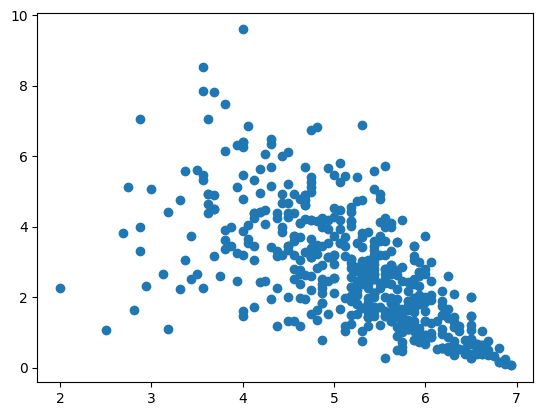

In [71]:
plt.scatter(df['mean'], df['var'])

In [72]:
subset = GUILT2[df['var'] >= 5]


print(f"Початкова альфа групи: {pg.cronbach_alpha(data=subset)[0]:.3f}\n")

# Цикл для перевірки 'Alpha if item deleted'
for item in subset.columns:
    # Створюємо список без одного поточного елемента
    reduced_items = [i for i in subset.columns if i != item]
    alpha, ci = pg.cronbach_alpha(data=subset[reduced_items])
    print(f"Альфа БЕЗ {item}: {alpha:.3f} (CI: {ci})")

Початкова альфа групи: 0.033

Альфа БЕЗ gasp_2: 0.277 (CI: [-0.167  0.571])
Альфа БЕЗ gasp_5: -0.015 (CI: [-0.638  0.397])
Альфа БЕЗ gasp_11: -0.106 (CI: [-0.786  0.343])
Альфа БЕЗ gasp_15: -0.149 (CI: [-0.854  0.318])


In [73]:
subset = GUILT2[df['var'] < 4]


print(subset)

print(f"Початкова альфа групи: {pg.cronbach_alpha(data=subset)[0]:.3f}\n")

# Цикл для перевірки 'Alpha if item deleted'
for item in subset.columns:
    # Створюємо список без одного поточного елемента
    reduced_items = [i for i in subset.columns if i != item]
    alpha, ci = pg.cronbach_alpha(data=subset[reduced_items])
    print(f"Альфа БЕЗ {item}: {alpha:.3f} (CI: {ci})")

     gasp_2  gasp_5  gasp_11  gasp_15
0         4       6        5        5
1         6       2        4        4
2         6       7        6        6
3         5       5        6        3
4         6       5        6        6
..      ...     ...      ...      ...
469       3       3        6        6
470       4       6        3        2
472       5       4        4        2
475       6       5        7        7
476       5       7        3        5

[371 rows x 4 columns]
Початкова альфа групи: 0.555

Альфа БЕЗ gasp_2: 0.533 (CI: [0.444 0.61 ])
Альфа БЕЗ gasp_5: 0.489 (CI: [0.392 0.573])
Альфа БЕЗ gasp_11: 0.436 (CI: [0.329 0.529])
Альфа БЕЗ gasp_15: 0.475 (CI: [0.375 0.561])


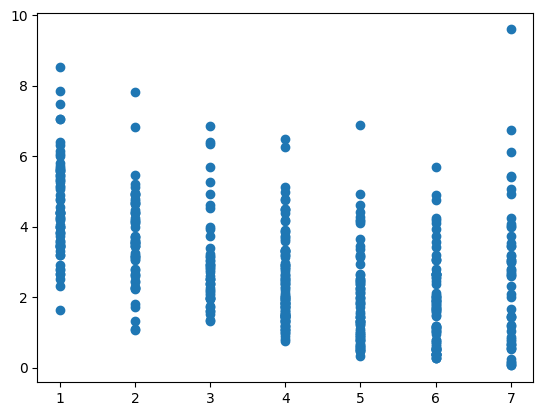

In [74]:
plt.scatter(df['gasp_16'], df['var'])

In [75]:
categories = [GUILT1, GUILT2, SHAME1, SHAME2]

for i, cat in enumerate(categories):
   df[f"var{i}"] = pd.Series([])
   for j in range(l):
      df[f'var{i}'][j] = to_reduce.loc[j][cat.columns].var()

df.head()

Показано результат, скорочений до останніх рядків (5000).
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[f'var{i}'][j] = to_reduce.loc[j][cat.columns].var()
/tmp/ipykernel_8099/2787554776.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'var{i}'][j] = to_reduce.loc[j][cat.columns].var()
/tmp/ipykernel_8099/2787554776.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will

,Позначка часу,вік,стать,діяльність,місце_проживання,gasp_1,gasp_2,gasp_3,gasp_4,gasp_5,...,gasp_14,gasp_15,gasp_16,before_reddit,mean,var,var0,var1,var2,var3
0,2026-04-23 20:49:48.767,2,2,1,1,6,4,6,3,6,...,6,5,3,1,4.75,2.6,2.0,0.666667,0.25,1.583333
1,2026-04-23 21:00:46.082,2,2,3,1,6,6,6,5,2,...,6,4,3,1,5.125,1.983333,2.25,2.666667,0.666667,0.916667
2,2026-04-23 21:11:07.659,2,2,3,5,5,6,5,7,7,...,6,6,7,1,5.375,1.45,0.916667,0.25,1.666667,2.0
3,2026-04-23 21:35:59.829,2,2,4,5,5,5,5,5,5,...,7,3,2,1,5.1875,2.295833,4.25,1.583333,0.916667,2.666667
4,2026-04-23 21:43:50.968,2,2,2,1,2,6,7,3,5,...,4,6,3,1,4.875,2.383333,0.916667,0.25,0.916667,2.25


(array([186., 113.,  71.,  38.,  31.,  20.,   7.,   8.,   2.,   2.]),
 array([ 0. ,  1.2,  2.4,  3.6,  4.8,  6. ,  7.2,  8.4,  9.6, 10.8, 12. ]),
 <BarContainer object of 10 artists>)

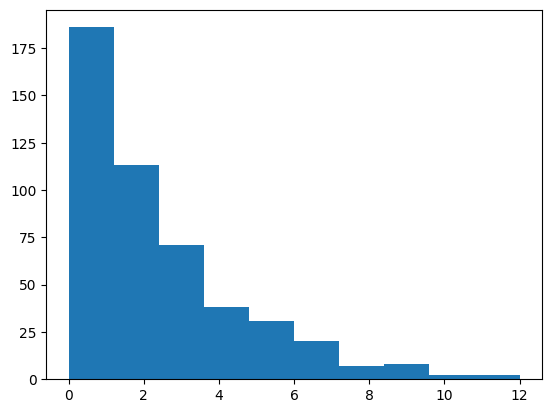

In [76]:
plt.hist(df['var3'], bins = 10)

In [77]:
subset = GUILT1


print(subset)

print(f"Початкова альфа групи: {pg.cronbach_alpha(data=subset)[0]:.3f}\n")

# Цикл для перевірки 'Alpha if item deleted'
for item in subset.columns:
    # Створюємо список без одного поточного елемента
    reduced_items = [i for i in subset.columns if i != item]
    alpha, ci = pg.cronbach_alpha(data=subset[reduced_items])
    print(f"Альфа БЕЗ {item}: {alpha:.3f} (CI: {ci})")

     gasp_1  gasp_9  gasp_14  gasp_16
0         6       5        6        3
1         6       4        6        3
2         5       5        6        7
3         5       5        7        2
4         2       4        4        3
..      ...     ...      ...      ...
473       3       1        1        1
474       7       7        7        6
475       7       6        7        6
476       6       5        6        3
477       7       2        1        4

[478 rows x 4 columns]
Початкова альфа групи: 0.652

Альфа БЕЗ gasp_1: 0.658 (CI: [0.601 0.708])
Альфа БЕЗ gasp_9: 0.568 (CI: [0.497 0.631])
Альфа БЕЗ gasp_14: 0.574 (CI: [0.504 0.636])
Альфа БЕЗ gasp_16: 0.520 (CI: [0.44 0.59])


In [78]:
dfw1 = df[df['стать'] == 2]
dfw2 = df2[df['стать'] == 2]
print(len(dfw1), len(dfw2))

219 63


/tmp/ipykernel_8099/2507708268.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfw2 = df2[df['стать'] == 2]


In [79]:
name_dict = {f"@{i}_питання": f'gasp_{i}' for i in range(1,17)}
name_dict

{'@1_питання': 'gasp_1',
 '@2_питання': 'gasp_2',
 '@3_питання': 'gasp_3',
 '@4_питання': 'gasp_4',
 '@5_питання': 'gasp_5',
 '@6_питання': 'gasp_6',
 '@7_питання': 'gasp_7',
 '@8_питання': 'gasp_8',
 '@9_питання': 'gasp_9',
 '@10_питання': 'gasp_10',
 '@11_питання': 'gasp_11',
 '@12_питання': 'gasp_12',
 '@13_питання': 'gasp_13',
 '@14_питання': 'gasp_14',
 '@15_питання': 'gasp_15',
 '@16_питання': 'gasp_16'}

In [80]:
dfw2 = dfw2.rename(columns = name_dict)
dfw2.head()

,група,вік,стать,діяльность,місце_проживання,gasp_1,gasp_2,gasp_3,gasp_4,gasp_5,...,gasp_7,gasp_8,gasp_9,gasp_10,gasp_11,gasp_12,gasp_13,gasp_14,gasp_15,gasp_16
0,1,2,2,1,1,7,6,7,3,7,...,4,2,6,7,6,6,4,6,5,5
1,1,2,2,3,3,4,7,7,3,2,...,5,1,3,7,6,2,1,1,1,1
2,1,2,2,3,1,5,6,7,7,7,...,6,7,7,7,7,7,7,7,7,5
3,1,2,2,3,1,7,5,7,7,4,...,4,2,7,7,2,3,6,6,4,6
4,1,2,2,1,4,7,4,7,6,7,...,3,3,7,7,6,6,7,7,3,7


In [81]:
categories = [[*a.columns] for a in categories]
categories

[['gasp_1', 'gasp_9', 'gasp_14', 'gasp_16'],
 ['gasp_2', 'gasp_5', 'gasp_11', 'gasp_15'],
 ['gasp_3', 'gasp_6', 'gasp_10', 'gasp_13'],
 ['gasp_4', 'gasp_7', 'gasp_8', 'gasp_12']]

In [82]:
dfw2[categories[0]]

,gasp_1,gasp_9,gasp_14,gasp_16
0,7,6,6,5
1,4,3,1,1
2,5,7,7,5
3,7,7,6,6
4,7,7,7,7
...,...,...,...,...
70,4,4,7,3
71,2,4,2,7
72,7,7,7,7
73,7,7,7,7


In [83]:


for subset in categories:
  print(f"Початкова альфа групи 2026: {pg.cronbach_alpha(data=dfw1[subset])[0]:.3f}")
  print(f"Початкова альфа групи 2025: {pg.cronbach_alpha(data=dfw2[subset])[0]:.3f}\n")

    # Цикл для перевірки 'Alpha if item deleted'
  for item in subset:
    reduced_items = [i for i in subset if i != item]
    alpha, ci = pg.cronbach_alpha(data=dfw1[reduced_items])
    print(f"2026: Альфа БЕЗ {item}: {alpha:.3f} (CI: {ci})")
    alpha, ci = pg.cronbach_alpha(data=dfw2[reduced_items])
    print(f"2025: Альфа БЕЗ {item}: {alpha:.3f} (CI: {ci})")
  print('\n\n')

Початкова альфа групи 2026: 0.655
Початкова альфа групи 2025: 0.800

2026: Альфа БЕЗ gasp_1: 0.649 (CI: [0.559 0.722])
2025: Альфа БЕЗ gasp_1: 0.806 (CI: [0.705 0.876])
2026: Альфа БЕЗ gasp_9: 0.536 (CI: [0.419 0.633])
2025: Альфа БЕЗ gasp_9: 0.703 (CI: [0.549 0.811])
2026: Альфа БЕЗ gasp_14: 0.610 (CI: [0.512 0.692])
2025: Альфа БЕЗ gasp_14: 0.758 (CI: [0.632 0.846])
2026: Альфа БЕЗ gasp_16: 0.536 (CI: [0.419 0.633])
2025: Альфа БЕЗ gasp_16: 0.718 (CI: [0.572 0.82 ])



Початкова альфа групи 2026: 0.481
Початкова альфа групи 2025: 0.637

2026: Альфа БЕЗ gasp_2: 0.563 (CI: [0.453 0.655])
2025: Альфа БЕЗ gasp_2: 0.677 (CI: [0.508 0.794])
2026: Альфа БЕЗ gasp_5: 0.389 (CI: [0.234 0.517])
2025: Альфа БЕЗ gasp_5: 0.540 (CI: [0.301 0.707])
2026: Альфа БЕЗ gasp_11: 0.310 (CI: [0.135 0.454])
2025: Альфа БЕЗ gasp_11: 0.531 (CI: [0.288 0.701])
2026: Альфа БЕЗ gasp_15: 0.348 (CI: [0.182 0.484])
2025: Альфа БЕЗ gasp_15: 0.517 (CI: [0.265 0.692])



Початкова альфа групи 2026: 0.601
Початкова альф

ПО цій таблиці видно, що питання 2 найгірше в обох вибірках, а питання 12 сильно погіршилося відносно першого дослідження

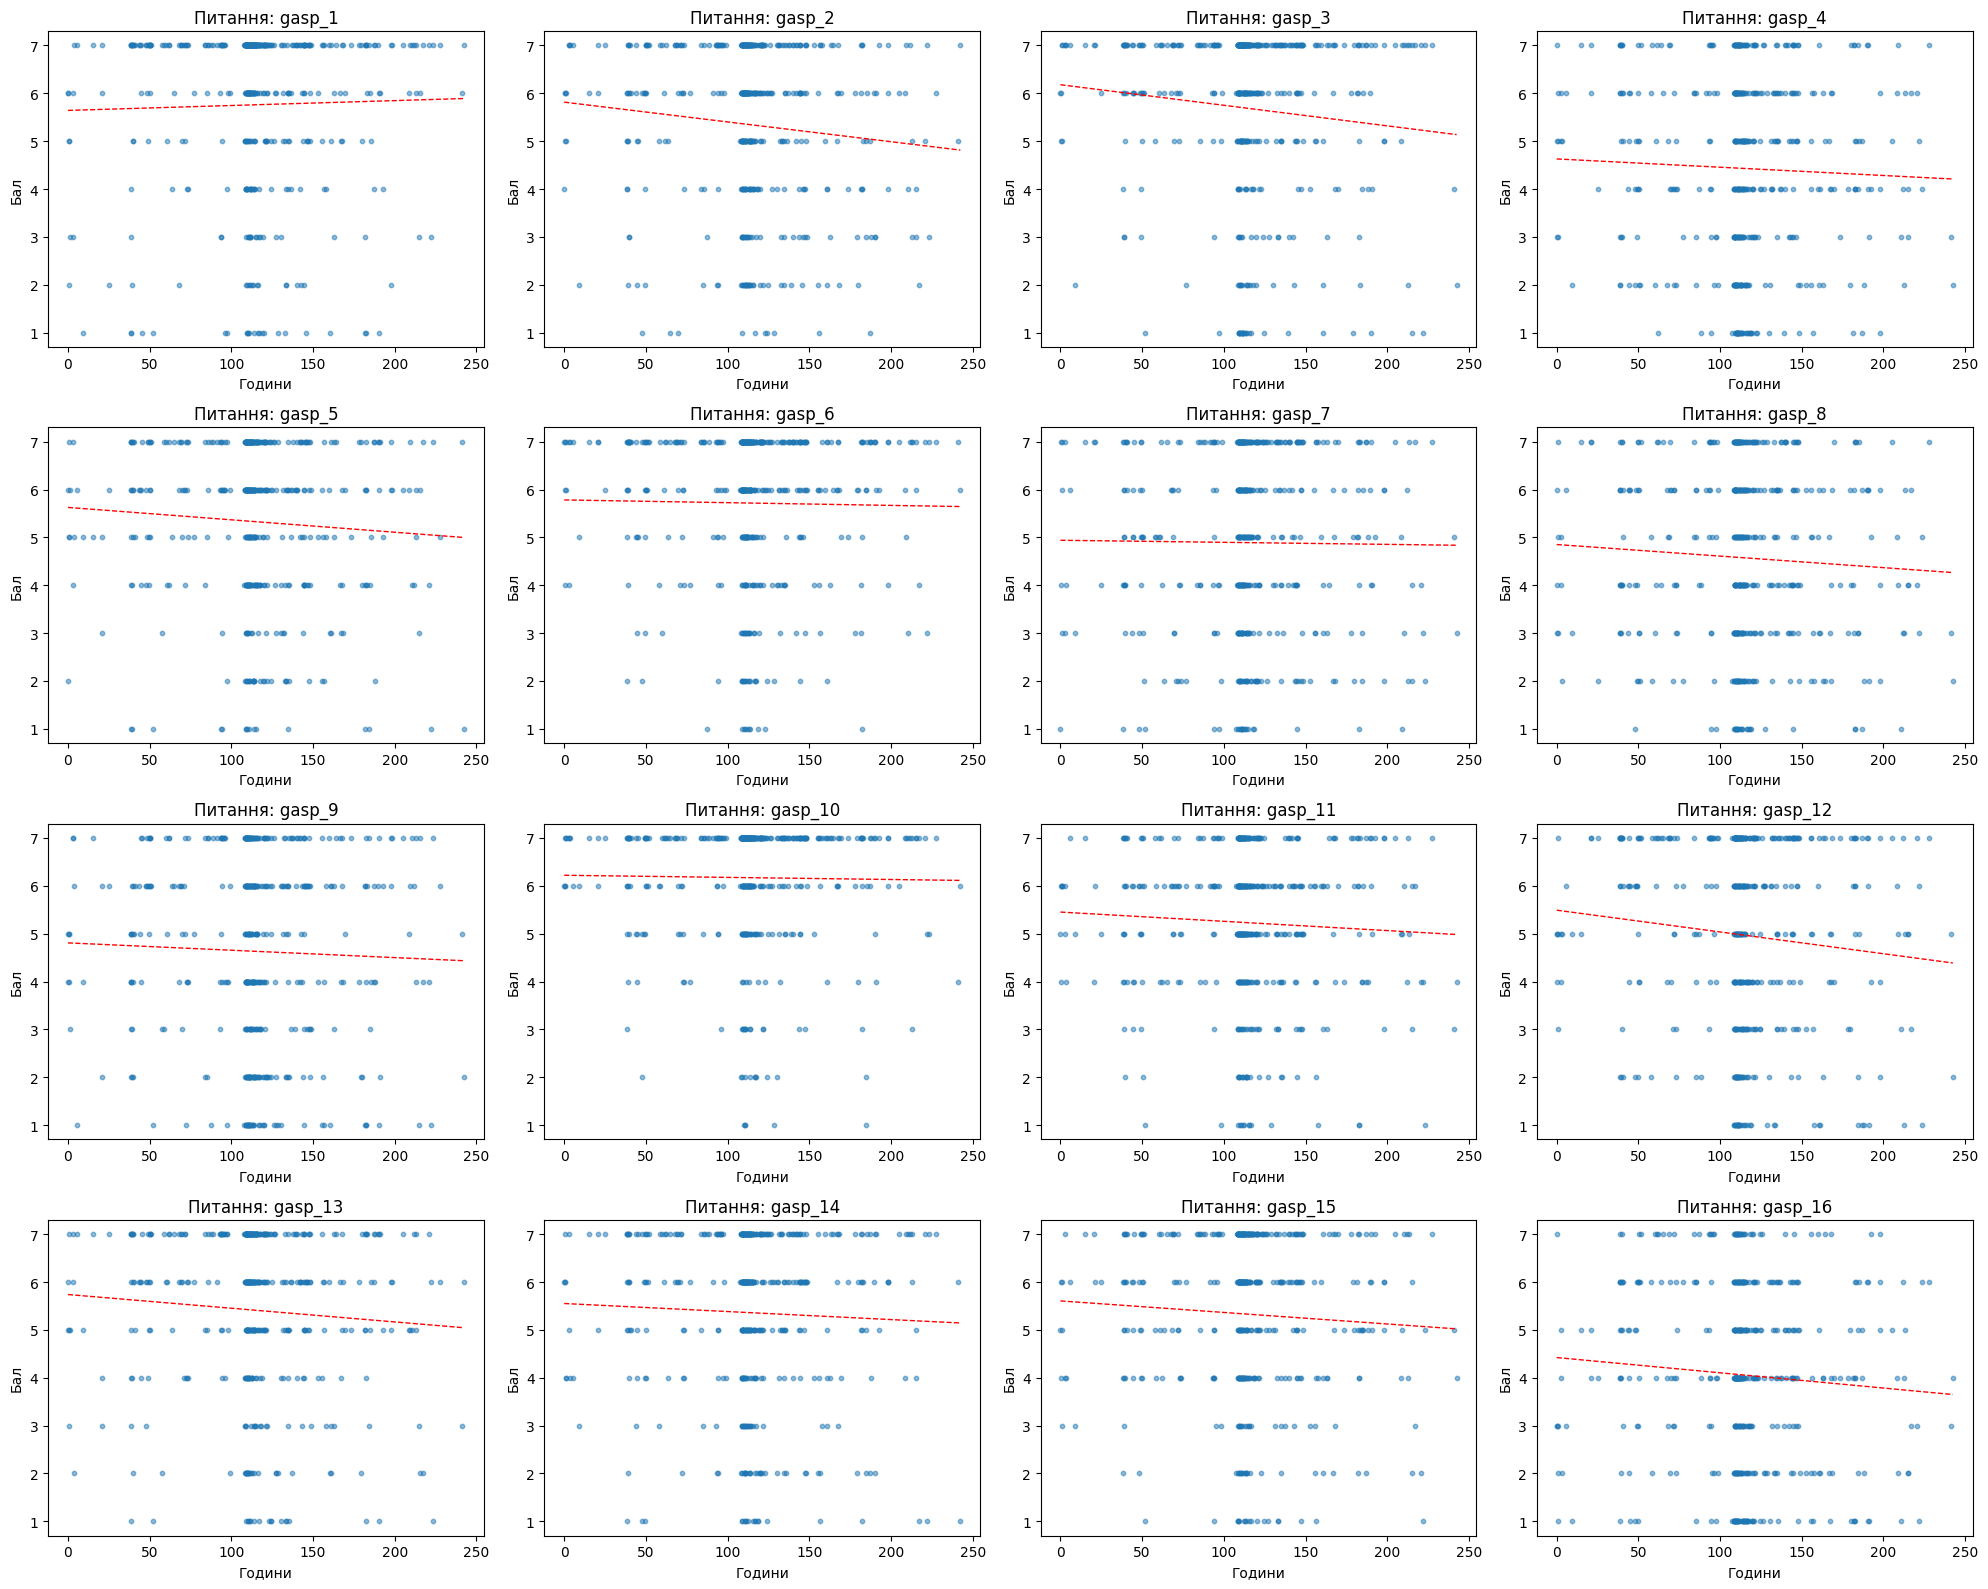

In [84]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Перетворюємо час у числову вісь (наприклад, години від найпершої відповіді)
# Якщо формат не datetime, pd.to_datetime його виправить
time_series = pd.to_datetime(df['Позначка часу'])
time_numeric = (time_series - time_series.min()).dt.total_seconds() / 3600  # у годинах

# 2. Налаштування сітки субплотів
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()  # Робимо масив плоским для зручної ітерації
column_names = to_reduce.columns

for i, col in enumerate(column_names):
    # Будуємо scatter plot
    axes[i].scatter(time_numeric, to_reduce[col], alpha=0.5, s=10)

    # Додаємо лінію тренду (червона), щоб побачити коваріацію
    z = np.polyfit(time_numeric, to_reduce[col], 1)
    p = np.poly1d(z)
    axes[i].plot(time_numeric, p(time_numeric), "r--", linewidth=1)

    axes[i].set_title(f'Питання: {col}')
    axes[i].set_xlabel('Години')
    axes[i].set_ylabel('Бал')

plt.tight_layout()
plt.show()

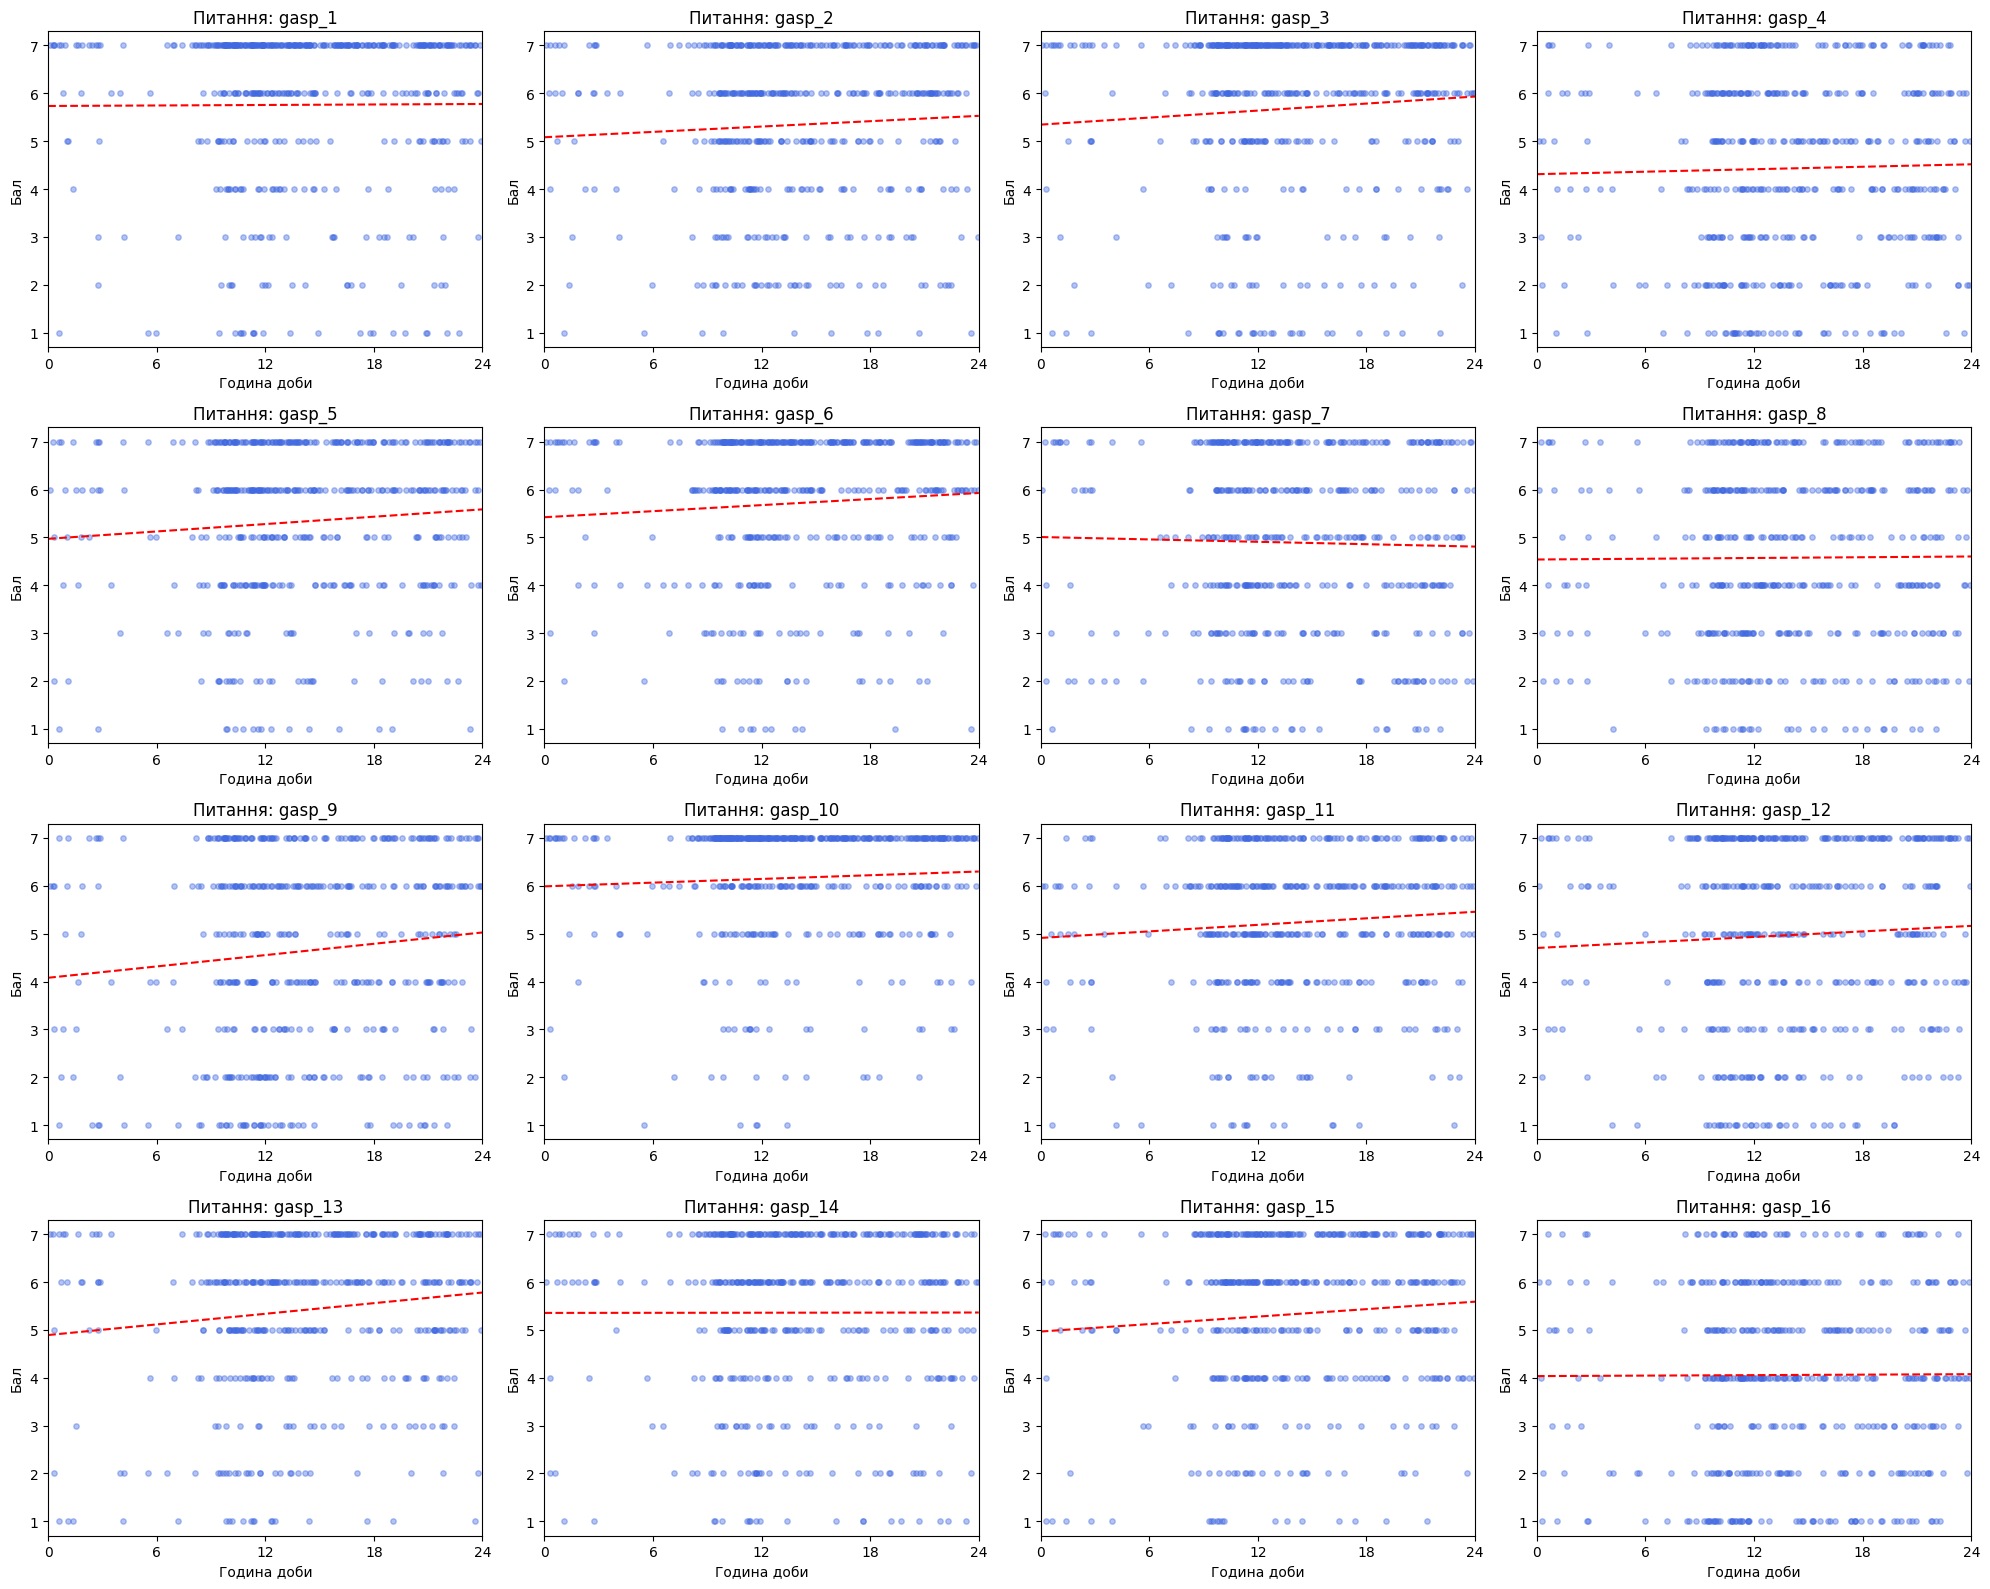

In [85]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Витягуємо час доби у форматі десяткового числа (наприклад, 14:30 -> 14.5)
time_series = pd.to_datetime(df['Позначка часу'])
# .hour (0-23) + .minute/60 + .second/3600
time_of_day = time_series.dt.hour + time_series.dt.minute/60 + time_series.dt.second/3600

# 2. Налаштування сітки субплотів 4x4
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()
column_names = to_reduce.columns

for i, col in enumerate(column_names):
    # Scatter plot: X - це година доби (від 0 до 24)
    axes[i].scatter(time_of_day, to_reduce[col], alpha=0.4, s=15, color='royalblue')

    # Лінія тренду для перевірки лінійної залежності від часу доби
    z = np.polyfit(time_of_day, to_reduce[col], 1)
    p = np.poly1d(z)

    # Створюємо точки для лінії від 0 до 24 годин
    x_range = np.linspace(0, 24, 100)
    axes[i].plot(x_range, p(x_range), "r--", label='Linear Trend')

    axes[i].set_title(f'Питання: {col}')
    axes[i].set_xlim(0, 24)  # Фіксуємо шкалу від півночі до півночі
    axes[i].set_xticks([0, 6, 12, 18, 24]) # Позначаємо ключові години
    axes[i].set_xlabel('Година доби')
    axes[i].set_ylabel('Бал')

plt.tight_layout()
plt.show()

Значимих кореляцій не виявлено

In [86]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Підготовка часової коваріати (використовуємо лінійний час у годинах)
time_series = pd.to_datetime(df['Позначка часу'])
X_time = ((time_series - time_series.min()).dt.total_seconds() / 3600).values.reshape(-1, 1)

# 2. Створення нового датафрейму для очищених даних
no_cov = pd.DataFrame(index=to_reduce.index, columns=to_reduce.columns)

for col in to_reduce.columns:
    y = to_reduce[col].values

    # Будуємо модель залежності конкретного питання від часу
    model = LinearRegression()
    model.fit(X_time, y)

    # Обчислюємо прогнозовані значення (тренд)
    trend = model.predict(X_time)

    # Видаляємо тренд: Оригінал - Прогноз + Середнє (щоб зберегти масштаб 1-7)
    no_cov[col] = y - trend + y.mean()

# Округлимо до 3 знаків для зручності
no_cov = no_cov.astype(float).round(3)

print("Дані очищено від часової коваріати.")
print(no_cov.head())

Дані очищено від часової коваріати.
   gasp_1  gasp_2  gasp_3  gasp_4  gasp_5  gasp_6  gasp_7  gasp_8  gasp_9  \
0   6.117   3.528   5.509   2.802   5.704   6.935   0.951   2.724   4.824   
1   6.117   5.529   5.510   4.803   1.704   6.935   6.951   5.725   3.825   
2   5.117   5.530   4.511   6.803   6.705   3.935   3.951   3.725   4.825   
3   5.116   4.531   4.513   4.804   4.706   5.935   2.951   6.726   4.825   
4   2.116   5.532   6.513   2.804   4.706   5.935   5.951   4.726   3.826   

   gasp_10  gasp_11  gasp_12  gasp_13  gasp_14  gasp_15  gasp_16  
0    5.949    4.779    3.480    5.673    5.808    4.725    2.636  
1    5.949    3.779    4.481    4.674    5.809    3.725    2.637  
2    5.950    5.780    4.482    2.674    5.809    5.726    6.637  
3    6.950    5.781    4.484    6.675    6.810    2.727    1.639  
4    6.950    5.781    2.485    4.676    3.810    5.727    2.639  


In [87]:
pg.cronbach_alpha(data = SHAME2)

(np.float64(0.6924032893949159), array([0.645, 0.735]))

In [88]:
pg.cronbach_alpha(data = no_cov[categories[3]])

(np.float64(0.6916328663224256), array([0.644, 0.734]))

Тест це підтверджує.

In [89]:
categories

[['gasp_1', 'gasp_9', 'gasp_14', 'gasp_16'],
 ['gasp_2', 'gasp_5', 'gasp_11', 'gasp_15'],
 ['gasp_3', 'gasp_6', 'gasp_10', 'gasp_13'],
 ['gasp_4', 'gasp_7', 'gasp_8', 'gasp_12']]

In [90]:
from scipy.stats import f

print(f.ppf(0.95, 6, 471))

2.117820653797988


In [91]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

binary = df[df['стать'] != 3]

for column in to_reduce.columns:
  model = ols(f'стать ~ C({column})', data=binary).fit()
  anova_table = sm.stats.anova_lm(model, typ=2)
  print(column)
  print(anova_table)
  print('\n\n')



gasp_1
               sum_sq     df         F    PR(>F)
C(gasp_1)    3.869942    6.0  2.643438  0.015677
Residual   113.946514  467.0       NaN       NaN



gasp_2
               sum_sq     df         F    PR(>F)
C(gasp_2)    3.169429    6.0  2.151711  0.046505
Residual   114.647027  467.0       NaN       NaN



gasp_3
               sum_sq     df         F    PR(>F)
C(gasp_3)    7.280552    6.0  5.126566  0.000041
Residual   110.535904  467.0       NaN       NaN



gasp_4
               sum_sq     df         F    PR(>F)
C(gasp_4)    4.714369    6.0  3.244282  0.003914
Residual   113.102087  467.0       NaN       NaN



gasp_5
               sum_sq     df         F    PR(>F)
C(gasp_5)    0.988212    6.0  0.658367  0.683389
Residual   116.828244  467.0       NaN       NaN



gasp_6
               sum_sq     df         F    PR(>F)
C(gasp_6)    5.395725    6.0  3.735674  0.001218
Residual   112.420731  467.0       NaN       NaN



gasp_7
               sum_sq     df         F    PR(>F)
C(

ANOVA доводить статистичну різницю між чоловіками та жінками для ряду питань, а саме 3, 6, 9 та 12

/tmp/ipykernel_8099/239547349.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axes[i].boxplot([male_data, female_data],
/tmp/ipykernel_8099/239547349.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axes[i].boxplot([male_data, female_data],
/tmp/ipykernel_8099/239547349.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axes[i].boxplot([male_data, female_data],
/tmp/ipykernel_8099/239547349.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = axes[i].bo

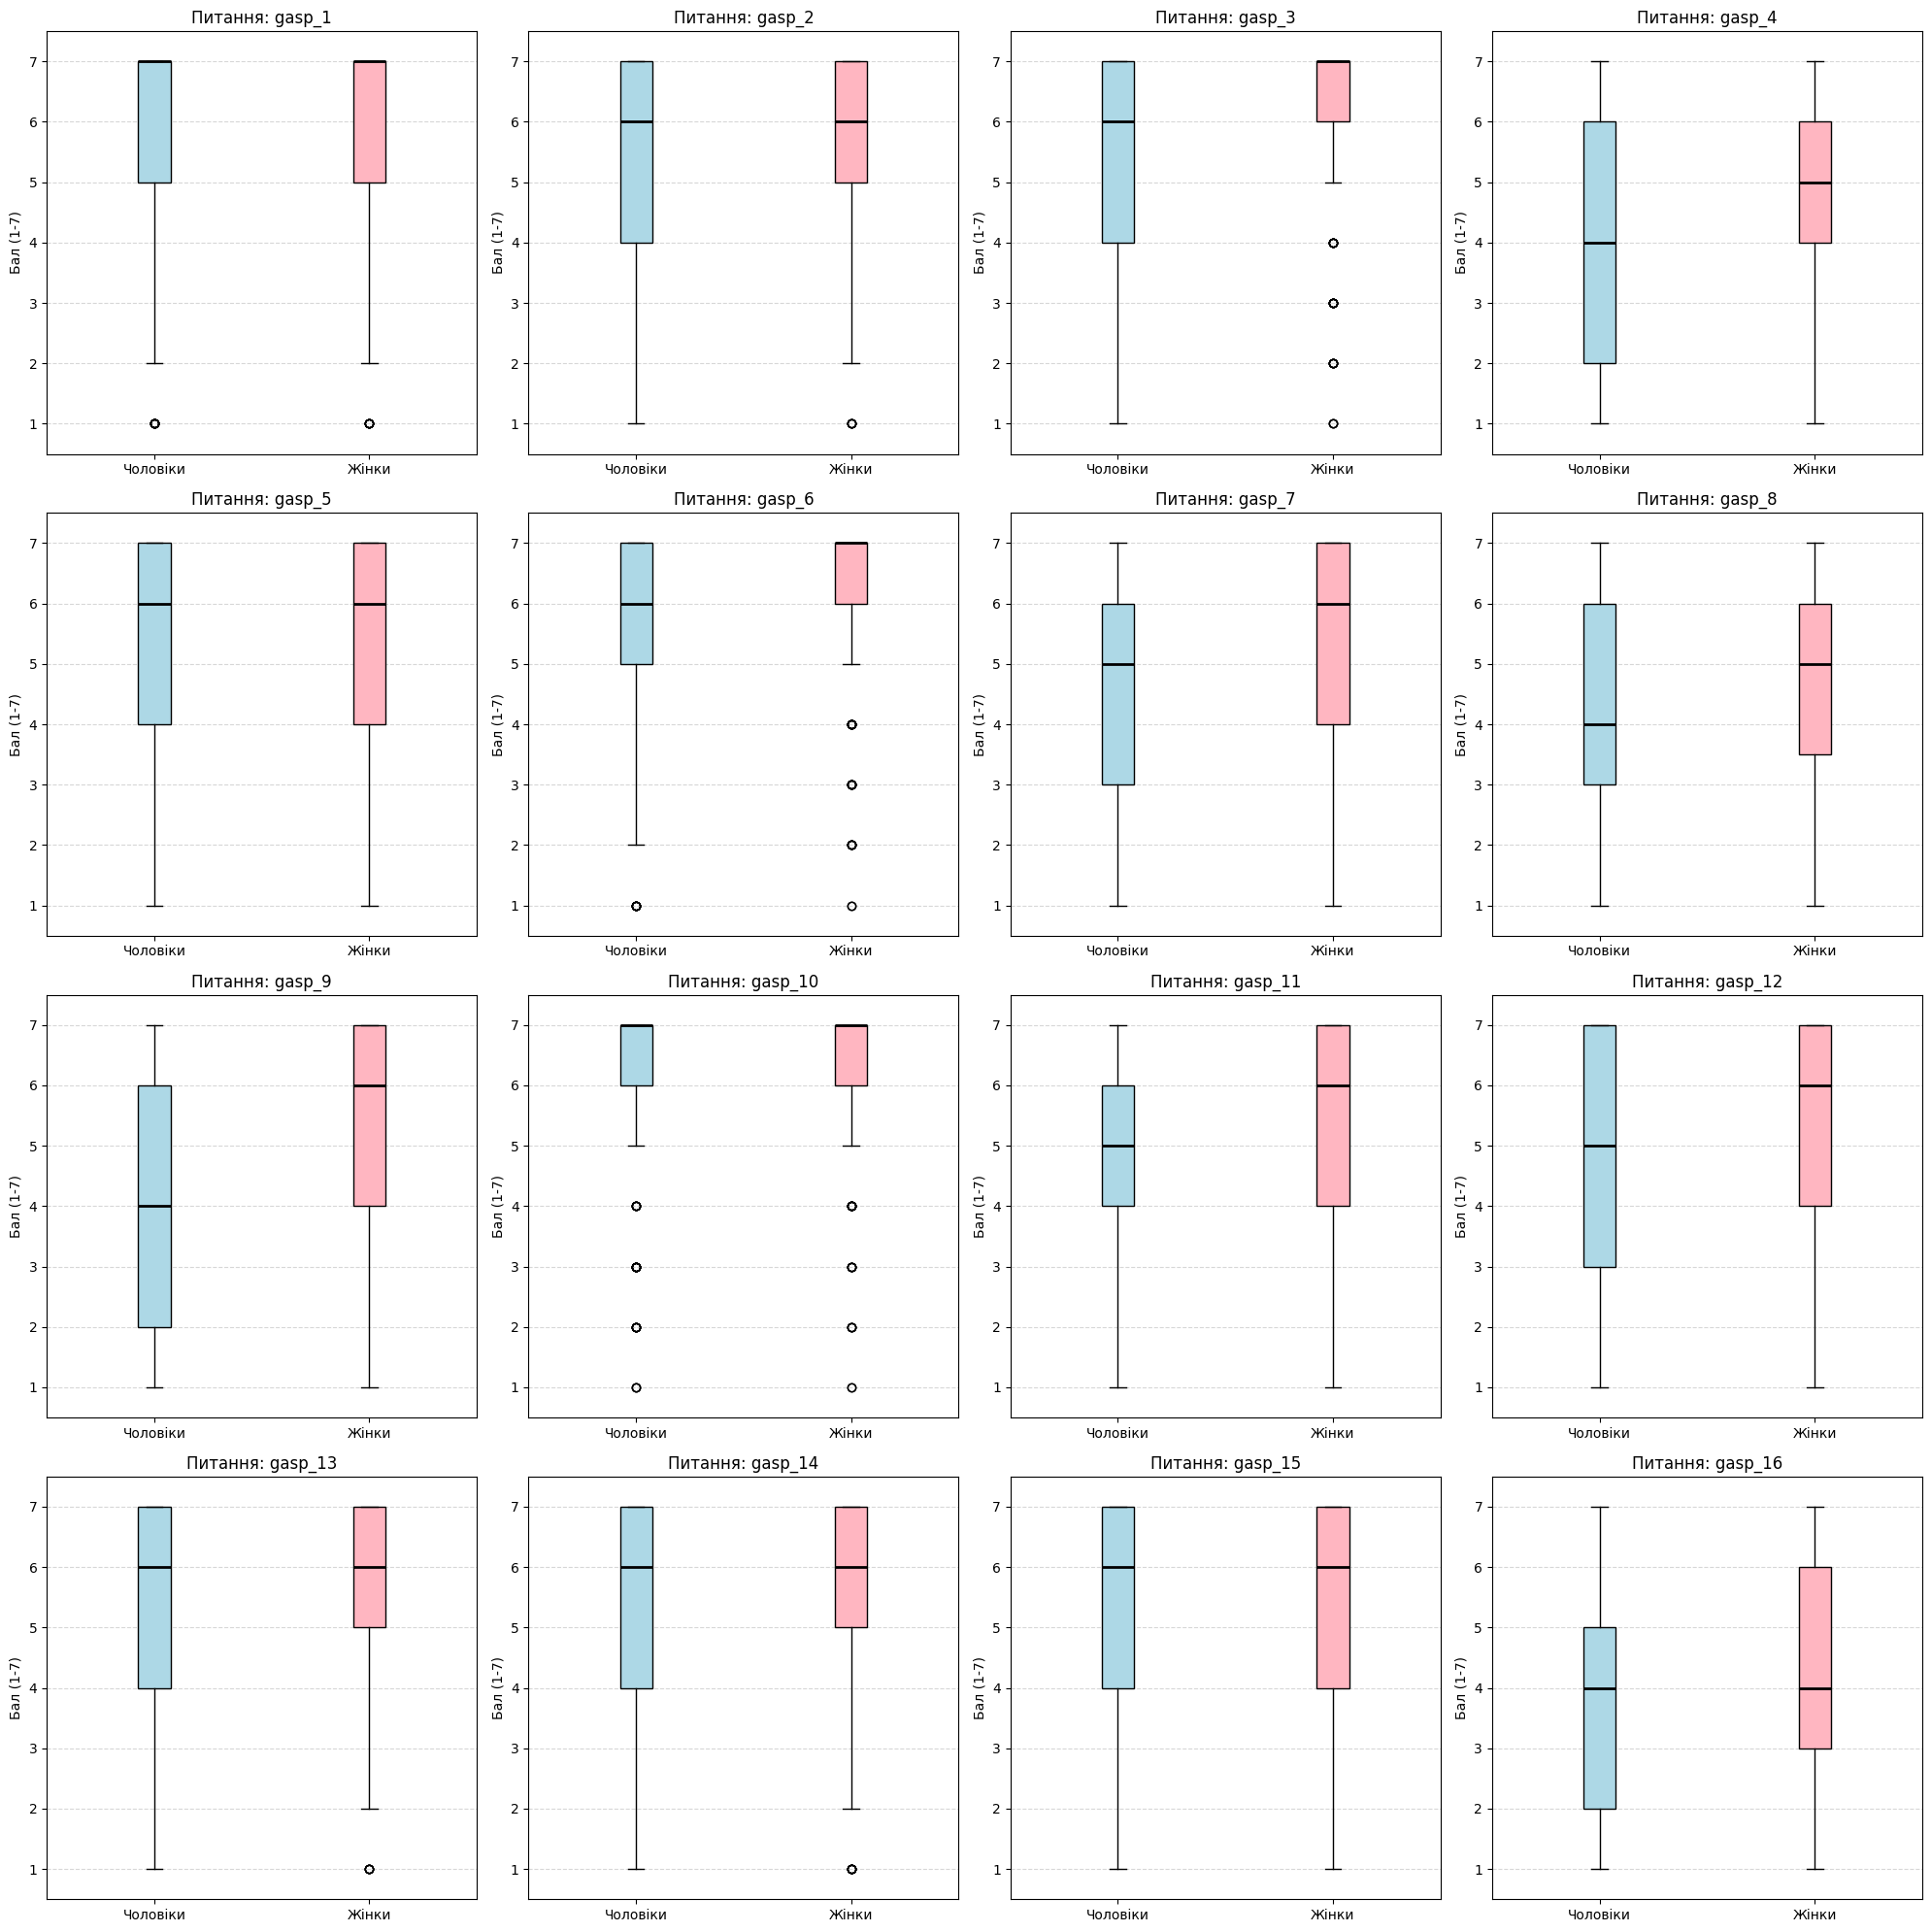

In [92]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(to_reduce.columns):
    male_data = binary[binary['стать'] == 1][col].dropna()
    female_data = binary[binary['стать'] == 2][col].dropna()

    bplot = axes[i].boxplot([male_data, female_data],
                            labels=['Чоловіки', 'Жінки'],
                            patch_artist=True,
                            medianprops=dict(color="black", linewidth=2))

    colors = ['lightblue', 'lightpink']
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    axes[i].set_title(f'Питання: {col}')
    axes[i].set_ylabel('Бал (1-7)')
    axes[i].set_ylim(0.5, 7.5)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Графіки також підтверджують, що тест необов'язково кращі для жінок. Тут працює ефект стелі - іноді жінки схильні відповідати екстремальніше, варіація падає, і здається, ніби їх відповіді більш узгоджені

In [93]:
print(binary.groupby('стать')[to_reduce.columns].std().mean(axis=1))

стать
1    1.824875
2    1.655143
dtype: float64


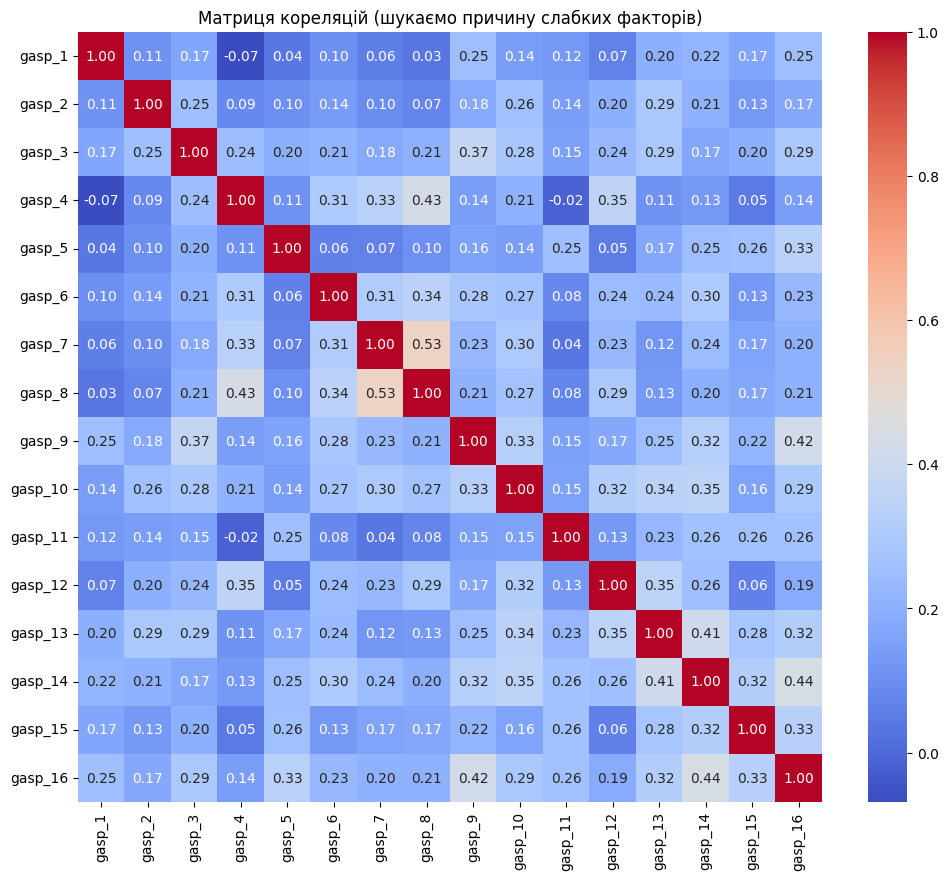

In [94]:
import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(to_reduce.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матриця кореляцій (шукаємо причину слабких факторів)")
plt.show()

In [95]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

# 1. Тест Бартлетта
chi_square_value, p_value = calculate_bartlett_sphericity(to_reduce)
print(f"Тест Бартлетта: Chi-square = {chi_square_value:.2f}, p-value = {p_value:.5f}")

# 2. Тест KMO
kmo_all, kmo_model = calculate_kmo(to_reduce)
print(f"Загальний показник KMO: {kmo_model:.3f}")

# Подивимось на KMO для кожного питання окремо
kmo_per_item = pd.Series(kmo_all, index=to_reduce.columns)
print("\nKMO для кожного питання:")
print(kmo_per_item.sort_values())

Тест Бартлетта: Chi-square = 1569.35, p-value = 0.00000
Загальний показник KMO: 0.855

KMO для кожного питання:
gasp_4     0.790500
gasp_8     0.795926
gasp_5     0.804670
gasp_7     0.810015
gasp_12    0.837813
gasp_1     0.837923
gasp_3     0.859432
gasp_11    0.860239
gasp_13    0.862843
gasp_15    0.868878
gasp_14    0.873464
gasp_9     0.873678
gasp_16    0.880644
gasp_2     0.888623
gasp_6     0.902987
gasp_10    0.915116
dtype: float64


In [96]:
for cat in categories:
    _, kmo_model = calculate_kmo(to_reduce[cat])
    print(f"Група {cat}: KMO = {kmo_model:.3f}")

Група ['gasp_1', 'gasp_9', 'gasp_14', 'gasp_16']: KMO = 0.703
Група ['gasp_2', 'gasp_5', 'gasp_11', 'gasp_15']: KMO = 0.643
Група ['gasp_3', 'gasp_6', 'gasp_10', 'gasp_13']: KMO = 0.698
Група ['gasp_4', 'gasp_7', 'gasp_8', 'gasp_12']: KMO = 0.695


Кореляція між сумарними балами груп:


,Group_1,Group_2,Group_3,Group_4
Group_1,1.000000,0.469710,0.560524,0.302479
Group_2,0.469710,1.000000,0.434136,0.203671
Group_3,0.560524,0.434136,1.000000,0.491791
Group_4,0.302479,0.203671,0.491791,1.000000


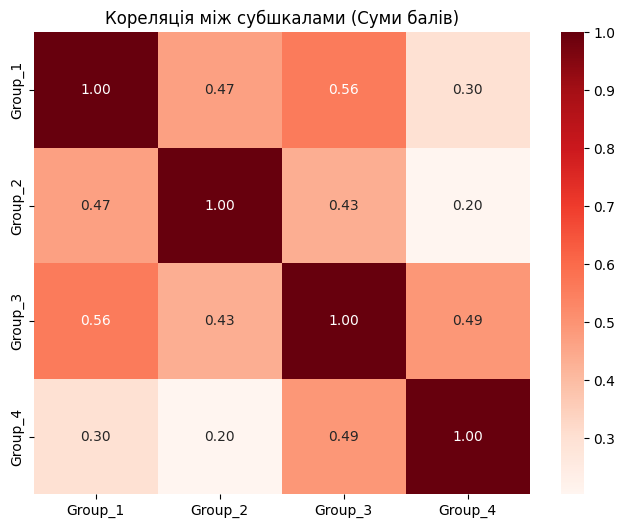

In [97]:
# 1. Створюємо новий датафрейм, де кожна колонка — це сума балів за групу
group_scores = pd.DataFrame()

for i, cols in enumerate(categories):
    group_scores[f'Group_{i+1}'] = to_reduce[cols].sum(axis=1)

# 2. Будуємо матрицю кореляцій між групами
groups_corr = group_scores.corr()

# 3. Виводимо результат
print("Кореляція між сумарними балами груп:")
display(groups_corr)

# Візуалізуємо, щоб побачити, наскільки вони "злиплися"
plt.figure(figsize=(8, 6))
sns.heatmap(groups_corr, annot=True, cmap='Reds', fmt=".2f")
plt.title("Кореляція між субшкалами (Суми балів)")
plt.show()

In [98]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X_scaled = StandardScaler().fit_transform(to_reduce)
to_cluster = PCA(n_components = 4).fit_transform(X_scaled)
df['DBSCAN'] = DBSCAN(eps = 0.8).fit_predict(to_cluster)

/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


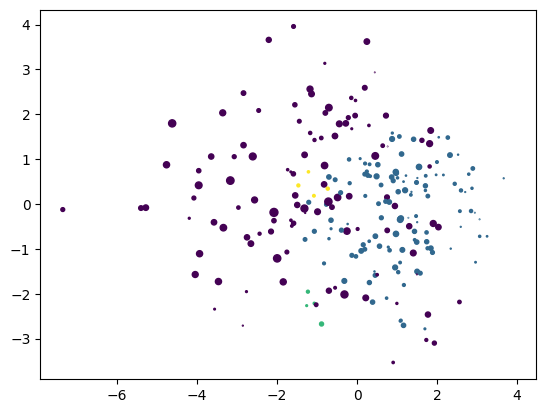

In [99]:
dim2 = PCA(n_components = 3).fit_transform(X_scaled)
plt.scatter(dim2[:,0], dim2[:,1], c = df['DBSCAN'], s = dim2[:,2] * 10)

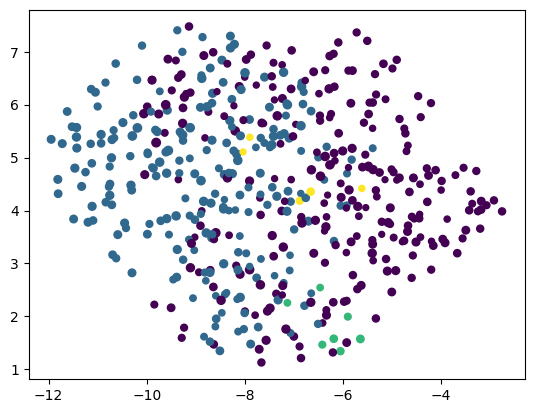

In [100]:
reducer = umap.UMAP(n_components=3, min_dist=0.8)

dots = reducer.fit_transform(X_scaled)

plt.scatter(dots[:,0], dots[:,1], s = dots[:, 2] * 4, c = df['DBSCAN'])

In [101]:
df['DBSCAN'].unique()

array([ 0, -1,  1,  2])

In [102]:
df[df['DBSCAN'] == -1]

,Позначка часу,вік,стать,діяльність,місце_проживання,gasp_1,gasp_2,gasp_3,gasp_4,gasp_5,...,gasp_15,gasp_16,before_reddit,mean,var,var0,var1,var2,var3,DBSCAN
1,2026-04-23 21:00:46.082,2,2,3,1,6,6,6,5,2,...,4,3,1,5.125,1.983333,2.25,2.666667,0.666667,0.916667,-1
2,2026-04-23 21:11:07.659,2,2,3,5,5,6,5,7,7,...,6,7,1,5.375,1.45,0.916667,0.25,1.666667,2.0,-1
4,2026-04-23 21:43:50.968,2,2,2,1,2,6,7,3,5,...,6,3,1,4.875,2.383333,0.916667,0.25,0.916667,2.25,-1
5,2026-04-23 21:48:40.829,2,2,2,1,3,5,7,6,6,...,5,1,1,5.125,3.45,1.583333,0.333333,1.0,3.583333,-1
8,2026-04-24 00:18:50.771,2,2,3,1,7,7,7,5,5,...,4,2,1,4.875,3.45,4.916667,2.0,6.25,2.0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472,2026-05-03 01:38:08.511,2,2,6,5,7,5,7,6,4,...,2,3,0,5.3125,3.029167,4.25,1.583333,0.0,2.25,-1
473,2026-05-03 02:45:43.899,2,1,1,5,3,7,1,5,1,...,1,1,0,3.1875,4.429167,1.0,8.25,4.916667,2.25,-1
474,2026-05-03 04:08:24.159,2,1,4,5,7,3,7,4,7,...,5,6,0,4.6875,5.695833,0.25,6.666667,8.0,3.333333,-1
476,2026-05-03 21:52:26.917,4,2,2,1,6,5,4,3,7,...,5,3,0,4.625,1.983333,2.0,2.666667,3.0,1.333333,-1


In [103]:
categories

[['gasp_1', 'gasp_9', 'gasp_14', 'gasp_16'],
 ['gasp_2', 'gasp_5', 'gasp_11', 'gasp_15'],
 ['gasp_3', 'gasp_6', 'gasp_10', 'gasp_13'],
 ['gasp_4', 'gasp_7', 'gasp_8', 'gasp_12']]

In [104]:
pg.cronbach_alpha(data = to_reduce[df['DBSCAN'] == -1][categories[3]])

(np.float64(0.6701195745863417), array([0.598, 0.732]))

In [133]:
to_reduce

,gasp_1,gasp_2,gasp_3,gasp_4,gasp_5,gasp_6,gasp_7,gasp_8,gasp_9,gasp_10,gasp_11,gasp_12,gasp_13,gasp_14,gasp_15,gasp_16
0,6,4,6,3,6,7,1,3,5,6,5,4,6,6,5,3
1,6,6,6,5,2,7,7,6,4,6,4,5,5,6,4,3
2,5,6,5,7,7,4,4,4,5,6,6,5,3,6,6,7
3,5,5,5,5,5,6,3,7,5,7,6,5,7,7,3,2
4,2,6,7,3,5,6,6,5,4,7,6,3,5,4,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,3,7,1,5,1,3,3,3,1,5,4,6,6,1,1,1
474,7,3,7,4,7,7,2,5,7,5,1,1,1,7,5,6
475,7,6,7,7,5,7,7,7,6,7,7,7,6,7,7,6
476,6,5,4,3,7,7,5,3,5,4,3,5,3,6,5,3


In [138]:
from factor_analyzer import FactorAnalyzer
fa = FactorAnalyzer(n_factors=4, rotation="promax")
fa.fit(to_reduce[df['DBSCAN'] == 0])
print(fa.get_factor_variance())
print(fa.loadings_)

(array([1.52507982, 1.20077253, 1.08917735, 0.70932357]), array([0.09531749, 0.07504828, 0.06807358, 0.04433272]), array([0.09531749, 0.17036577, 0.23843936, 0.28277208]))
[[-0.10762733  0.30030358 -0.00910054  0.03995331]
 [-0.04311636 -0.0416147   0.10174179  0.64474289]
 [-0.0122996  -0.18558672  0.53628326  0.19515155]
 [ 0.42773833 -0.06834132  0.2931148  -0.14503597]
 [-0.10743103  0.09986047  0.54700257 -0.0560269 ]
 [ 0.43399789  0.00716141 -0.0091508   0.10551654]
 [ 0.62217713  0.00518083 -0.24908308  0.14646639]
 [ 0.84263327 -0.07971956 -0.08164318 -0.11975897]
 [-0.06966351 -0.06599074  0.36705369  0.13270758]
 [ 0.09782585  0.15565125  0.07766039  0.16115366]
 [ 0.07109001  0.07941828  0.06729407  0.29474945]
 [ 0.07670026  0.31776209 -0.01241242  0.03162225]
 [ 0.03987306  0.51686371  0.24068133 -0.13107504]
 [-0.00768357  0.64072093 -0.11235973 -0.11424378]
 [-0.01201521  0.4323021  -0.05409586  0.13246986]
 [ 0.06589469  0.23004671  0.34395188 -0.06006163]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [106]:
from factor_analyzer import FactorAnalyzer
fa = FactorAnalyzer(n_factors=4, rotation="promax")
fa.fit(to_reduce[df['DBSCAN'] == -1])
print(fa.get_factor_variance())
print(fa.loadings_)

(array([2.05191017, 1.47627271, 1.35464392, 1.22890707]), array([0.12824439, 0.09226704, 0.08466524, 0.07680669]), array([0.12824439, 0.22051143, 0.30517667, 0.38198337]))
[[-0.25380755 -0.14290378 -0.08739283  0.63923582]
 [-0.1378525  -0.04450094  0.45608994 -0.02780719]
 [ 0.13332314  0.03887072  0.17874109  0.22360109]
 [ 0.74570142 -0.10498477  0.07199073 -0.29136402]
 [ 0.10569275  0.69133589 -0.09371806 -0.2522015 ]
 [ 0.31925237 -0.05983102  0.11756527  0.17256459]
 [ 0.68515962  0.05566929 -0.18586554  0.02537096]
 [ 0.75921998  0.06176169 -0.17689648 -0.05082122]
 [ 0.17850843 -0.01232413 -0.01951473  0.60278545]
 [ 0.20163524  0.01035423  0.36595416  0.15166366]
 [-0.21680053  0.5508102   0.12361111 -0.11754377]
 [ 0.25883999 -0.14155514  0.60043899 -0.27215476]
 [-0.19894684  0.13121747  0.65366695  0.02132735]
 [ 0.05182558  0.3797969   0.25369521  0.13590259]
 [ 0.05189576  0.51970313 -0.10762303  0.08672811]
 [ 0.0648819   0.44458477  0.00893769  0.29551194]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [107]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

# 1. Тест Бартлетта
chi_square_value, p_value = calculate_bartlett_sphericity(to_reduce[df['DBSCAN'] == 0])
print(f"Тест Бартлетта: Chi-square = {chi_square_value:.2f}, p-value = {p_value:.5f}")

# 2. Тест KMO
kmo_all, kmo_model = calculate_kmo(to_reduce)
print(f"Загальний показник KMO: {kmo_model:.3f}")

# Подивимось на KMO для кожного питання окремо
kmo_per_item = pd.Series(kmo_all, index=to_reduce.columns)
print("\nKMO для кожного питання:")
print(kmo_per_item.sort_values())

Тест Бартлетта: Chi-square = 412.44, p-value = 0.00000
Загальний показник KMO: 0.855

KMO для кожного питання:
gasp_4     0.790500
gasp_8     0.795926
gasp_5     0.804670
gasp_7     0.810015
gasp_12    0.837813
gasp_1     0.837923
gasp_3     0.859432
gasp_11    0.860239
gasp_13    0.862843
gasp_15    0.868878
gasp_14    0.873464
gasp_9     0.873678
gasp_16    0.880644
gasp_2     0.888623
gasp_6     0.902987
gasp_10    0.915116
dtype: float64


Без кластеру

In [108]:
for cat in categories:
    _, kmo_model = calculate_kmo(to_reduce[df['DBSCAN'] == -1][cat])
    print(f"Група {cat}: KMO = {kmo_model:.3f}")

Група ['gasp_1', 'gasp_9', 'gasp_14', 'gasp_16']: KMO = 0.651
Група ['gasp_2', 'gasp_5', 'gasp_11', 'gasp_15']: KMO = 0.615
Група ['gasp_3', 'gasp_6', 'gasp_10', 'gasp_13']: KMO = 0.651
Група ['gasp_4', 'gasp_7', 'gasp_8', 'gasp_12']: KMO = 0.664


Кластер 0


In [139]:
for cat in categories:
    _, kmo_model = calculate_kmo(to_reduce[df['DBSCAN'] == 0][cat])
    print(f"Група {cat}: KMO = {kmo_model:.3f}")

Група ['gasp_1', 'gasp_9', 'gasp_14', 'gasp_16']: KMO = 0.493
Група ['gasp_2', 'gasp_5', 'gasp_11', 'gasp_15']: KMO = 0.579
Група ['gasp_3', 'gasp_6', 'gasp_10', 'gasp_13']: KMO = 0.606
Група ['gasp_4', 'gasp_7', 'gasp_8', 'gasp_12']: KMO = 0.580


Повна група

In [109]:
for cat in categories:
    _, kmo_model = calculate_kmo(to_reduce[cat])
    print(f"Група {cat}: KMO = {kmo_model:.3f}")

Група ['gasp_1', 'gasp_9', 'gasp_14', 'gasp_16']: KMO = 0.703
Група ['gasp_2', 'gasp_5', 'gasp_11', 'gasp_15']: KMO = 0.643
Група ['gasp_3', 'gasp_6', 'gasp_10', 'gasp_13']: KMO = 0.698
Група ['gasp_4', 'gasp_7', 'gasp_8', 'gasp_12']: KMO = 0.695


In [142]:
df.columns

Index(['Позначка часу', 'вік', 'стать', 'діяльність', 'місце_проживання',
       'gasp_1', 'gasp_2', 'gasp_3', 'gasp_4', 'gasp_5', 'gasp_6', 'gasp_7',
       'gasp_8', 'gasp_9', 'gasp_10', 'gasp_11', 'gasp_12', 'gasp_13',
       'gasp_14', 'gasp_15', 'gasp_16', 'before_reddit', 'mean', 'var', 'var0',
       'var1', 'var2', 'var3', 'DBSCAN'],
      dtype='object')

Оскільки обидва класи налічують майже половину всієї вибірки, а також не дуже відрізняються кількісно, можна зробити висновок про негшативний внесок кластеру 0 до загальної узгодженості

In [183]:
df_chi = df[df['DBSCAN'].isin([0,-1])][df['стать'].isin([1,2])]
import pandas as pd
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_chi['стать'], df_chi['DBSCAN'])

print("Таблиця спряженості:")
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Статистика Chi-square: {chi2:.4f}")
print(f"p-value: {p:.4e}")
print(f"Ступені свободи: {dof}")

Таблиця спряженості:
DBSCAN   -1    0
стать           
1       150   98
2        98  116
Статистика Chi-square: 9.3870
p-value: 2.1852e-03
Ступені свободи: 1


/tmp/ipykernel_8099/3552422718.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_chi = df[df['DBSCAN'].isin([0,-1])][df['стать'].isin([1,2])]


In [184]:
p < 0.05

np.True_

In [195]:
dfg = df[ df['вік'] == 1]

for subset in categories:
  print(f"Початкова альфа групи 2026: {pg.cronbach_alpha(data=dfg[subset])[0]:.3f}")

    # Цикл для перевірки 'Alpha if item deleted'
  for item in subset:
    reduced_items = [i for i in subset if i != item]
    alpha, ci = pg.cronbach_alpha(data=dfg[reduced_items])
    print(f"2026: Альфа БЕЗ {item}: {alpha:.3f} (CI: {ci})")
  print('\n\n')

Початкова альфа групи 2026: 0.634
2026: Альфа БЕЗ gasp_1: 0.532 (CI: [0.232 0.727])
2026: Альфа БЕЗ gasp_9: 0.539 (CI: [0.245 0.731])
2026: Альфа БЕЗ gasp_14: 0.693 (CI: [0.496 0.821])
2026: Альфа БЕЗ gasp_16: 0.464 (CI: [0.122 0.688])



Початкова альфа групи 2026: 0.508
2026: Альфа БЕЗ gasp_2: 0.596 (CI: [0.338 0.765])
2026: Альфа БЕЗ gasp_5: 0.267 (CI: [-0.202  0.573])
2026: Альфа БЕЗ gasp_11: 0.422 (CI: [0.052 0.663])
2026: Альфа БЕЗ gasp_15: 0.389 (CI: [-0.002  0.644])



Початкова альфа групи 2026: 0.562
2026: Альфа БЕЗ gasp_3: 0.285 (CI: [-0.173  0.583])
2026: Альфа БЕЗ gasp_6: 0.596 (CI: [0.338 0.765])
2026: Альфа БЕЗ gasp_10: 0.535 (CI: [0.237 0.729])
2026: Альфа БЕЗ gasp_13: 0.472 (CI: [0.135 0.692])



Початкова альфа групи 2026: 0.717
2026: Альфа БЕЗ gasp_4: 0.683 (CI: [0.481 0.815])
2026: Альфа БЕЗ gasp_7: 0.574 (CI: [0.301 0.752])
2026: Альфа БЕЗ gasp_8: 0.678 (CI: [0.472 0.812])
2026: Альфа БЕЗ gasp_12: 0.674 (CI: [0.466 0.81 ])





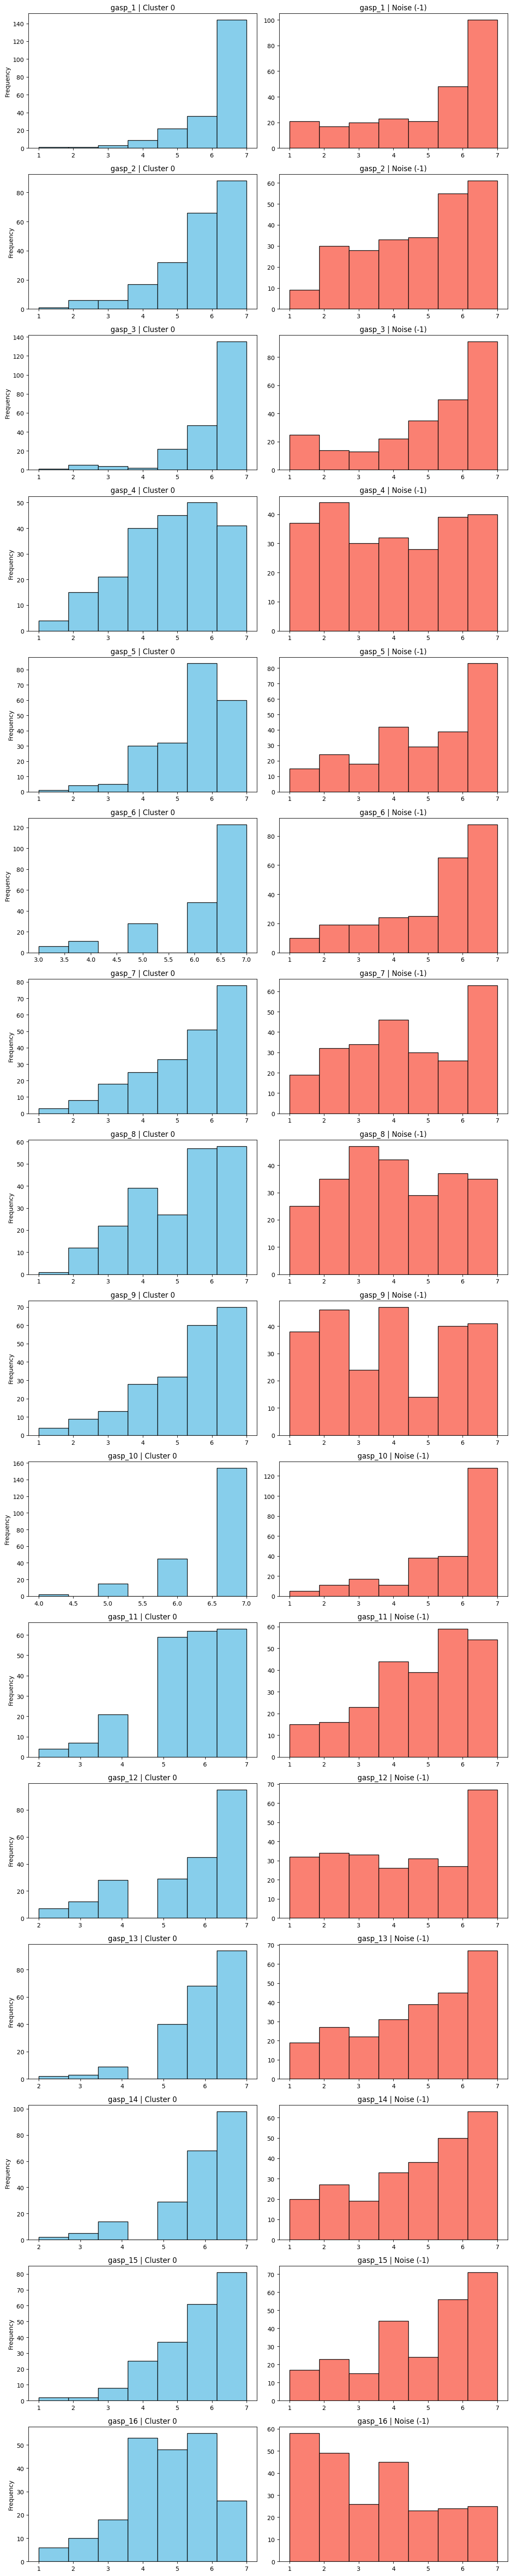

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns


gasp_columns = [f'gasp_{i}' for i in range(1, 17)]

fig, axes = plt.subplots(nrows=16, ncols=2, figsize=(12, 60))

for i, col in enumerate(gasp_columns):
    axes[i, 0].hist(df[df['DBSCAN'] == 0][col], bins=7, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f"{col} | Cluster 0")
    axes[i, 0].set_ylabel("Frequency")

    axes[i, 1].hist(df[df['DBSCAN'] == -1][col], bins=7, color='salmon', edgecolor='black')
    axes[i, 1].set_title(f"{col} | Noise (-1)")

plt.tight_layout()
plt.show()

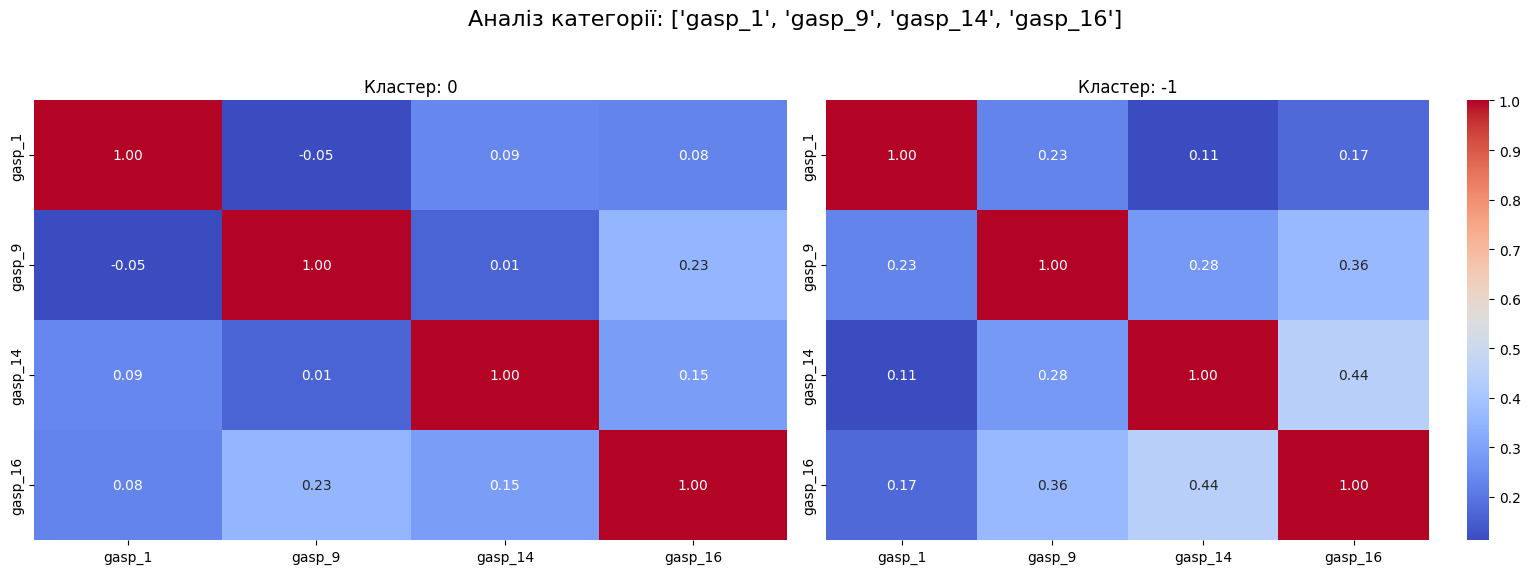

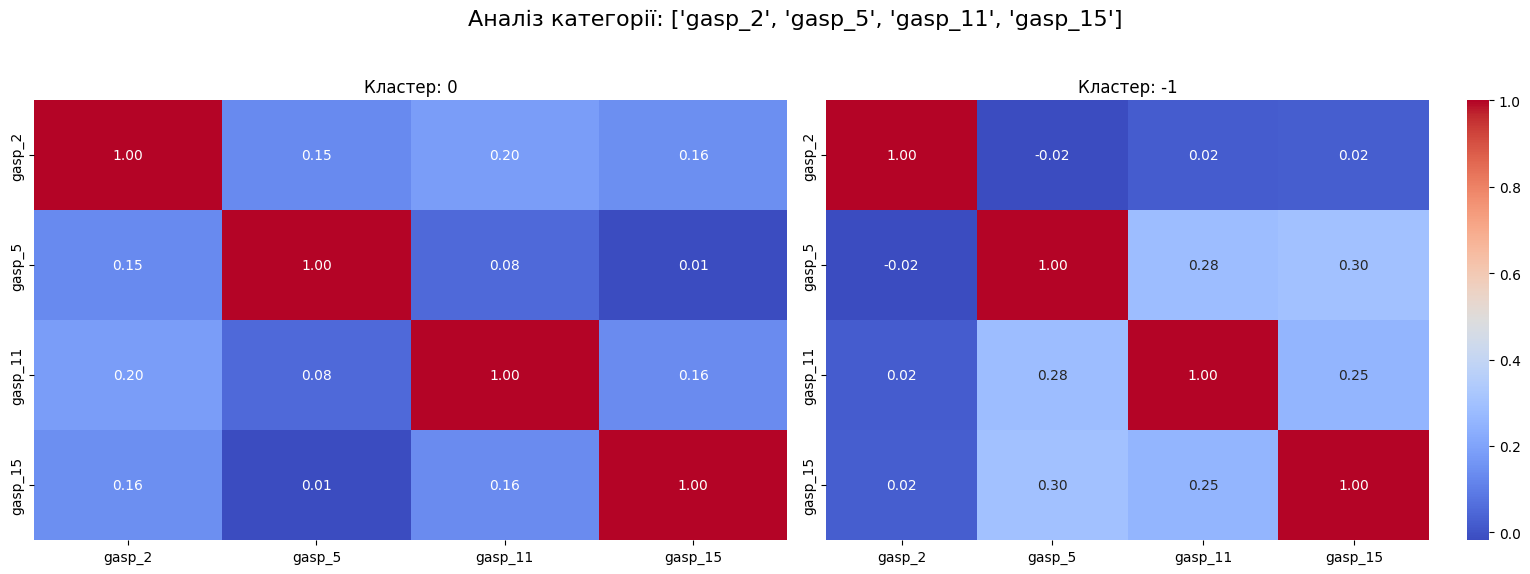

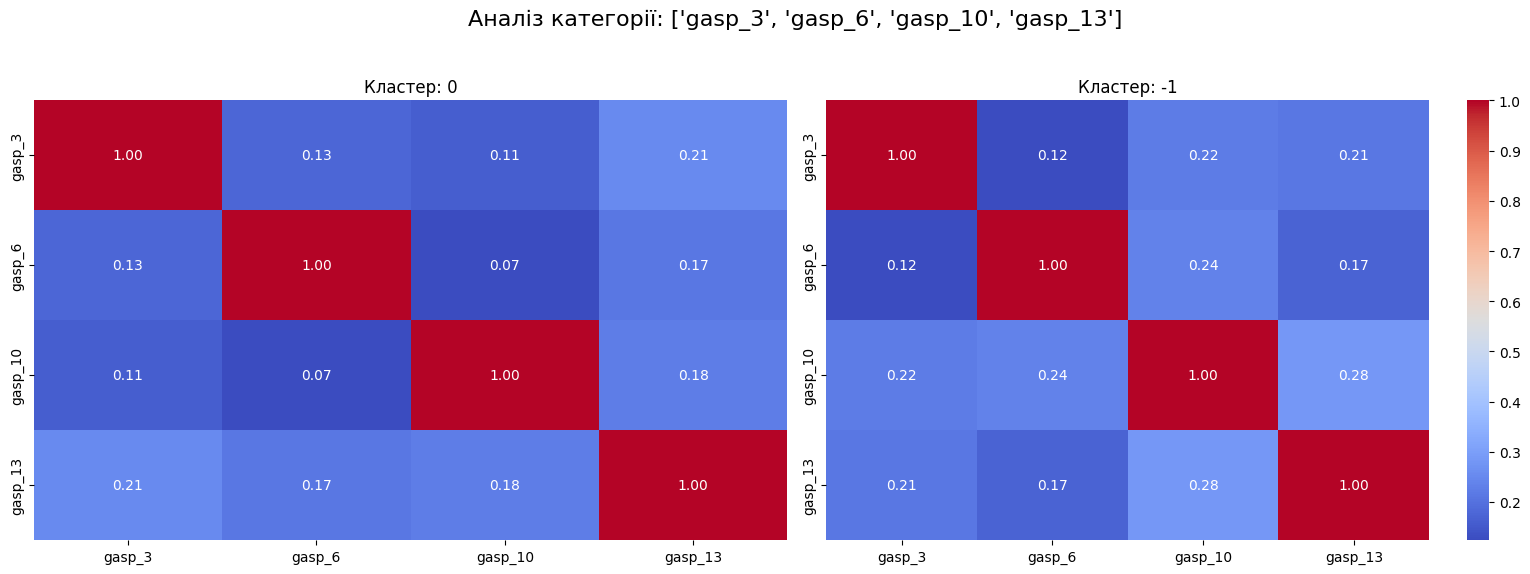

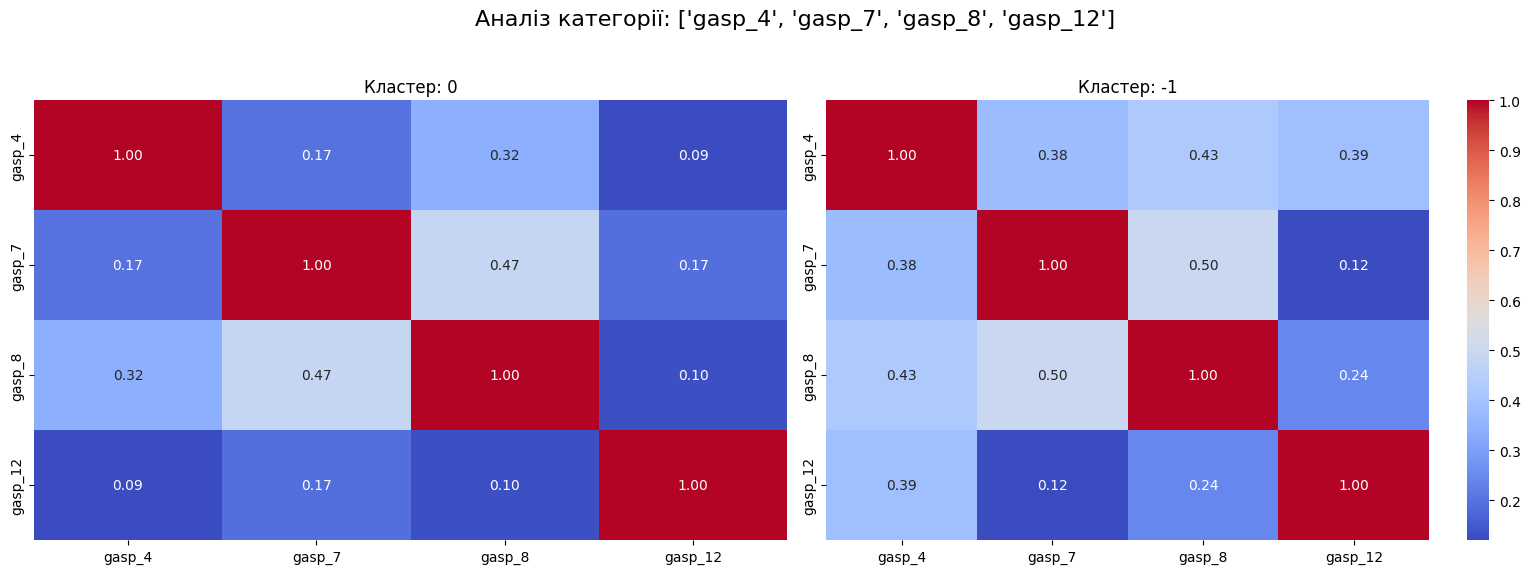

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

# Список категорій (замініть на ваші реальні назви колонок)
# categories = ['col1', 'col2', 'col3']

clusters_to_compare = [0, -1]

for cat in categories:
    # Створюємо фігуру з двома підграфіками (1 рядок, 2 стовпці)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Аналіз категорії: {cat}", fontsize=16)

    for i, cluster_val in enumerate(clusters_to_compare):
        # Фільтруємо дані за кластером
        data_subset = to_reduce[df['DBSCAN'] == cluster_val][cat]

        if not data_subset.empty:
            # Малюємо хітмап кореляцій для конкретної категорії всередині кластера
            # (Або ви можете малювати розподіл sns.histplot чи sns.boxplot,
            # якщо cat — це одна колонка)

            sns.heatmap(data_subset.corr(), annot=True, cmap='coolwarm',
                        fmt=".2f", ax=axes[i], cbar=(i == 1))

            axes[i].set_title(f"Кластер: {cluster_val}")
        else:
            axes[i].set_title(f"Кластер {cluster_val} (немає даних)")
            axes[i].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('corrplot.png')
    plt.show()

In [112]:
to_reduce.columns

Index(['gasp_1', 'gasp_2', 'gasp_3', 'gasp_4', 'gasp_5', 'gasp_6', 'gasp_7',
       'gasp_8', 'gasp_9', 'gasp_10', 'gasp_11', 'gasp_12', 'gasp_13',
       'gasp_14', 'gasp_15', 'gasp_16'],
      dtype='object')

In [113]:
df_discrete = df[df['DBSCAN'] == 0]
qs = [f'gasp_{i}' for i in range(1,17)]
qs_means = [df_discrete[q].mean() for q in qs]
qs_stds = [df_discrete[q].std() for q in qs]
for i, q in enumerate(qs):
  df_discrete[q] = df_discrete[q].apply(lambda x : 3 if x < 7 else 7)

print(df_discrete.head())
print(qs_means)
print(qs_stds)


            Позначка часу  вік  стать  діяльність  місце_проживання  gasp_1  \
0 2026-04-23 20:49:48.767    2      2           1                 1       3   
3 2026-04-23 21:35:59.829    2      2           4                 5       3   
6 2026-04-23 23:40:08.909    2      1           1                 5       3   
7 2026-04-23 23:43:47.295    2      2           3                 1       3   
9 2026-04-24 02:26:20.631    2      2           2                 1       7   

   gasp_2  gasp_3  gasp_4  gasp_5  ...  gasp_15  gasp_16  before_reddit  \
0       3       3       3       3  ...        3        3              1   
3       3       3       3       3  ...        3        3              1   
6       7       7       3       7  ...        3        3              1   
7       7       7       3       3  ...        7        3              1   
9       7       7       3       3  ...        3        3              1   

     mean       var      var0      var1      var2      var3  DBSCAN  
0   

/tmp/ipykernel_8099/2865969569.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_discrete[q] = df_discrete[q].apply(lambda x : 3 if x < 7 else 7)


In [114]:
pg.cronbach_alpha(data = df[df['DBSCAN'] == 0][to_reduce.columns])

(np.float64(0.6730412150281694), array([0.606, 0.733]))

In [115]:
pg.cronbach_alpha(data = df_discrete[to_reduce.columns])

(np.float64(0.7298491152860087), array([0.674, 0.78 ]))

In [116]:
for cat in categories:
  print(pg.cronbach_alpha(data=df_discrete[cat]))

(np.float64(0.3991436846744749), array([0.257, 0.52 ]))
(np.float64(0.4291545957334744), array([0.294, 0.544]))
(np.float64(0.44834689673458616), array([0.318, 0.559]))
(np.float64(0.5584598088813943), array([0.454, 0.647]))


In [117]:
for cat in categories:
  print(pg.cronbach_alpha(data=df[df['DBSCAN'] == 0][cat]))

(np.float64(0.28428419524111936), array([0.115, 0.428]))
(np.float64(0.3686340529477783), array([0.219, 0.496]))
(np.float64(0.39827813833081827), array([0.256, 0.519]))
(np.float64(0.5393461749520125), array([0.43 , 0.632]))


In [118]:
for cat in categories:
  print(pg.cronbach_alpha(data=df[df['DBSCAN'] == -1][cat]))

(np.float64(0.5902834357645237), array([0.501, 0.667]))
(np.float64(0.40135621041407354), array([0.27 , 0.514]))
(np.float64(0.5043806678111948), array([0.396, 0.598]))
(np.float64(0.6701195745863417), array([0.598, 0.732]))


(array([  1.,   8.,  10.,  29.,  48.,  81., 106., 109.,  53.,  33.]),
 array([2.     , 2.49375, 2.9875 , 3.48125, 3.975  , 4.46875, 4.9625 ,
        5.45625, 5.95   , 6.44375, 6.9375 ]),
 <BarContainer object of 10 artists>)

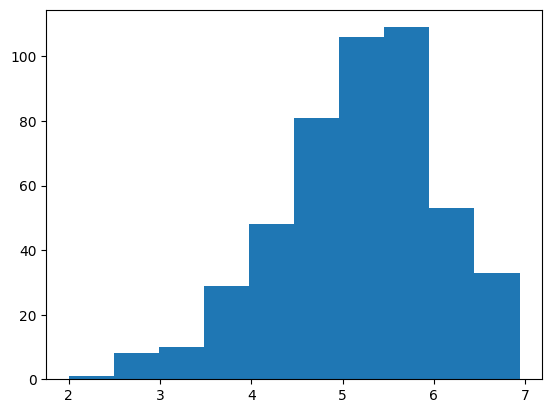

In [119]:
plt.hist(df['mean'], bins = 10)

In [120]:
df_filtered = df[df['DBSCAN'] == 0][df['mean'] > 6]
df_filtered

/tmp/ipykernel_8099/1200786200.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df[df['DBSCAN'] == 0][df['mean'] > 6]


,Позначка часу,вік,стать,діяльність,місце_проживання,gasp_1,gasp_2,gasp_3,gasp_4,gasp_5,...,gasp_15,gasp_16,before_reddit,mean,var,var0,var1,var2,var3,DBSCAN
11,2026-04-24 11:56:24.722,2,2,3,1,7,6,7,7,5,...,7,5,1,6.5625,0.6625,1.0,0.916667,0.0,1.0,0
19,2026-04-25 11:26:56.570,2,2,2,2,7,6,7,7,7,...,6,6,1,6.5,0.4,0.916667,0.333333,0.25,0.333333,0
28,2026-04-25 12:45:58.133,2,2,3,1,5,7,7,7,7,...,7,5,1,6.625,0.65,1.0,0.0,0.0,0.0,0
29,2026-04-25 12:46:58.869,2,2,3,2,7,6,6,6,6,...,6,6,1,6.5,0.266667,0.333333,0.0,0.25,0.25,0
30,2026-04-25 13:17:14.682,3,2,3,2,7,7,7,6,7,...,5,6,1,6.1875,0.5625,0.916667,1.0,0.333333,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,2026-05-01 19:09:46.917,2,2,1,1,6,3,7,7,6,...,6,6,0,6.375,1.05,0.333333,2.25,0.0,0.25,0
461,2026-05-02 02:51:29.882,2,2,4,5,7,7,7,6,6,...,5,5,0,6.375,0.516667,0.916667,0.916667,0.25,0.25,0
462,2026-05-02 09:50:27.095,2,2,2,3,7,6,7,5,6,...,7,5,0,6.5625,0.529167,1.0,0.333333,0.25,1.0,0
468,2026-05-02 17:58:57.799,2,2,2,1,7,5,7,6,5,...,7,5,0,6.25,0.866667,1.0,1.0,0.0,0.666667,0


In [121]:
for cat in categories:
  print(pg.cronbach_alpha(data=df_filtered[cat]))

(np.float64(0.4091758929587539), array([0.131, 0.614]))
(np.float64(0.08589215996623419), array([-0.344,  0.404]))
(np.float64(0.10133160116921076), array([-0.321,  0.414]))
(np.float64(0.35144992526158436), array([0.047, 0.577]))


In [122]:
for cat in categories:
  print(pg.cronbach_alpha(data=df[cat]))

(np.float64(0.6518373040832799), array([0.598, 0.7  ]))
(np.float64(0.4845365161968669), array([0.405, 0.556]))
(np.float64(0.5936025850155722), array([0.531, 0.65 ]))
(np.float64(0.6924032893949159), array([0.645, 0.735]))


In [123]:
df.columns

Index(['Позначка часу', 'вік', 'стать', 'діяльність', 'місце_проживання',
       'gasp_1', 'gasp_2', 'gasp_3', 'gasp_4', 'gasp_5', 'gasp_6', 'gasp_7',
       'gasp_8', 'gasp_9', 'gasp_10', 'gasp_11', 'gasp_12', 'gasp_13',
       'gasp_14', 'gasp_15', 'gasp_16', 'before_reddit', 'mean', 'var', 'var0',
       'var1', 'var2', 'var3', 'DBSCAN'],
      dtype='object')

In [124]:
index = [i for i in range(0,479)]
saved = df[['стать', 'вік', "діяльність", 'місце_проживання', "before_reddit", "Позначка часу", 'DBSCAN']]
saved['index'] = pd.Series(index)
saved.to_excel('кластери.xlsx')

/tmp/ipykernel_8099/2095677614.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['index'] = pd.Series(index)


In [125]:
df.corr()

,Позначка часу,вік,стать,діяльність,місце_проживання,gasp_1,gasp_2,gasp_3,gasp_4,gasp_5,...,gasp_15,gasp_16,before_reddit,mean,var,var0,var1,var2,var3,DBSCAN
Позначка часу,1.000000,-0.090315,-0.040694,-0.072191,-0.011947,0.024136,-0.100991,-0.100055,-0.037164,-0.063852,...,-0.058672,-0.068961,-0.718072,-0.097257,0.076767,0.006615,0.129643,0.097519,-0.022925,-0.070199
вік,-0.090315,1.000000,0.064508,0.302019,-0.008335,0.214365,0.113652,0.077501,-0.062095,0.059154,...,0.129253,0.157453,0.175596,0.109890,-0.088308,-0.056947,-0.116033,-0.075285,0.011284,0.053703
стать,-0.040694,0.064508,1.000000,0.031336,-0.003077,0.017610,0.101124,0.223616,0.181854,0.019269,...,0.064463,0.097137,0.364036,0.215655,-0.185845,-0.135125,-0.095767,-0.166409,-0.031985,0.101615
діяльність,-0.072191,0.302019,0.031336,1.000000,0.047841,-0.013914,0.075903,0.044027,0.050294,-0.012879,...,0.039143,0.068552,0.125563,0.070397,-0.032701,-0.009631,-0.057714,-0.086344,0.088480,-0.027102
місце_проживання,-0.011947,-0.008335,-0.003077,0.047841,1.000000,0.085261,0.081021,0.058025,-0.016167,0.076973,...,-0.011634,0.015710,0.053649,0.018787,-0.031332,-0.001999,-0.052589,-0.031506,0.032901,0.007026
gasp_1,0.024136,0.214365,0.017610,-0.013914,0.085261,1.000000,0.107701,0.169030,-0.068575,0.039862,...,0.165997,0.254351,-0.011563,0.350363,-0.221187,-0.023430,-0.179059,-0.145439,0.012338,0.279462
gasp_2,-0.100991,0.113652,0.101124,0.075903,0.081021,0.107701,1.000000,0.253672,0.085284,0.101048,...,0.129799,0.174865,0.093456,0.415810,-0.243263,-0.200440,-0.328101,-0.233822,-0.074729,0.277366
gasp_3,-0.100055,0.077501,0.223616,0.044027,0.058025,0.169030,0.253672,1.000000,0.244513,0.196524,...,0.197703,0.293569,0.125242,0.551196,-0.379180,-0.264175,-0.276299,-0.572302,-0.089099,0.246946
gasp_4,-0.037164,-0.062095,0.181854,0.050294,-0.016167,-0.068575,0.085284,0.244513,1.000000,0.111618,...,0.047426,0.142595,0.077361,0.453644,-0.352501,-0.082977,-0.107507,-0.194130,-0.283455,0.211159
gasp_5,-0.063852,0.059154,0.019269,-0.012879,0.076973,0.039862,0.101048,0.196524,0.111618,1.000000,...,0.257247,0.334635,0.064254,0.399586,-0.223227,-0.285491,-0.249893,-0.114936,-0.160469,0.217696
